# **DEEP LEARNING PROJECT** on visual grounding






> Mateo Rodriguez, Nicola Debole




---
# Preliminary study
## Papers
We have been reading a lot of papers to understand how to face this visual-grounding problem, like for example:
*   [Generation and Comprehension of Unambiguous Object Descriptions](https://arxiv.org/pdf/1511.02283.pdf)
*   [Modeling Context in Referring Expressions](https://arxiv.org/pdf/1608.00272.pdf)
*   [Grounding DINO: Marrying DINO with Grounded Pre-Training for Open-Set Object Detection](https://arxiv.org/pdf/2303.05499.pdf)

## Considerations
Of course model such as GoundingDINO are SOTA and would performs very well, we thought that the goal of this project is to learn how to build a model and so simply reading a paper and following the "instructions" is not the way we like to proceed. Instead, we decided to try and come up with our own solution (even if it is not the best) and using those papers just as a general guideline on what (not) to do.

## CLIP understanding
Since we had to work with CLIP it is important in our opinion to fully understand what that model is capable of. Our findings in no particular order:
1.   The model cannot understand negative sencences, for example even when prompted "not the black cat" the embeddings were most similar (using cosine similarity) to a cat than anything else.
2.   The model cannot understand spacial references or information about the location of the object. We tried with some pictures of a cat in many different areas of the image and then different promps with "left", "right", "up", "down" and other spacial clues but with no success.
That is why decided to include a **BERT** model in our pipeline, as it is capable of emedding spacial information in the text it receives as input.

## YOLO understanding (and why we choose not to use it)
Having already a box regression model (with also the ability to classify the object) is for sure a nice to have feature, but from our initial tests it was not able to recognize most of the object in an image. Sure, it correctly recognizes at least one object for every image but since in the REFCOCO dataset there are REALLY some strange images and labels, YOLO in not capable to find them all.
Also, for the purpose of the project it removes a big chunk of "freedom" (to try different techniques) so we decided not to use it.







# Code


## Disclaimer
Using Colab for a project like this is very annoying in our opinion, for reasons such as the limit on GPU usage and the difficulty when handling such big datasets.
Many time the kernel crashed for no reason at all and since we have available our own GPU we mainly worked locally. We then had to adapt the code for this ipynb file and manage to upload our dataset on the drive without having some errors in the process (due to internet connection or expiring sessions). We tried our best and hope it will be enough, but just in case we are also providing our GitHub repository were we developed the project and all the Weight And Biases logs for the different models we tried. These links be located at the end of the report.

## How to run the code

### Install the requirements

In [1]:
!pip install transformers
!pip install git+https://github.com/openai/CLIP.git

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 57.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.8/236.8 kB 29.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 121.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 77.4 MB/s eta 0:00:00
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-ztwbdek7
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-ztwbdek7
  Resolved https://github.com/openai/CLIP.git to commit a9b1bf5920416aaeaec965c25dd9e8f98c864f16
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 3.7 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=13693

### Mount the drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Set the folder location
Import the "Submission" folder in your drive by adding a shortcut in your desired location (e.g. in your main drive folder). Set the location in the variable below:


In [ ]:
submission_folder_path = '/content/drive/MyDrive/Project/Submission/'

# Be sure to put "/" at the end of the path!

In [3]:
submission_folder_path = '/content/drive/MyDrive/2s/Machine Learning/Project/Submission/'

---
# CLIP implementation
We decided not to finetune CLIP but instead freeze it and use the model to process the image and remove everything that is not relevant to the text in input. To be able to do that we are subdividing the image in smaller chunks and then for each "window" of chucks (could be 3x3, 4x4, etc.) we run the window thru CLIP and get the cosine similarity between the CLIP vector embedding we get from the text.

Then after we have a score for each window we can compute the score for each single chunk, normalize it and use this value as the similarity between that part of the image and the text.

Here we have an example of our idea to make it simpler to understand.

Showing COCO_test2014_000000021750.jpg


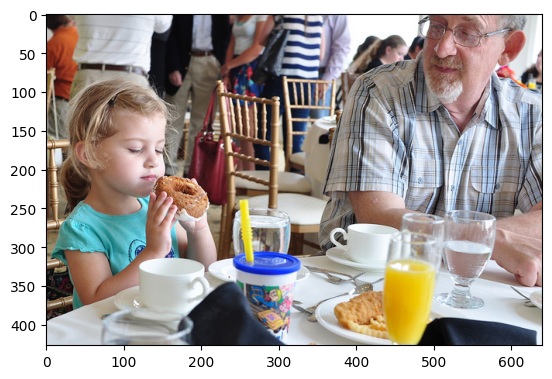

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import torch
import clip
import os
from torchvision import transforms
toTensor = transforms.ToTensor()

demo_path = submission_folder_path + '/Report_assets/clip_pre_example/'
demo_image_name = os.listdir(demo_path)[0]
image_path = os.path.join(demo_path,demo_image_name)
print('Showing',demo_image_name)
image = Image.open(image_path)

# Convert the image to tensor
image = toTensor(image).to('cpu')
# Plot the image (move the channels at the last dimension)
plt.imshow(image.to('cpu').permute(1,2,0))

Chunk the image in blocks of size 32x32

Tensor shape: torch.Size([1, 13, 20, 3, 32, 32])


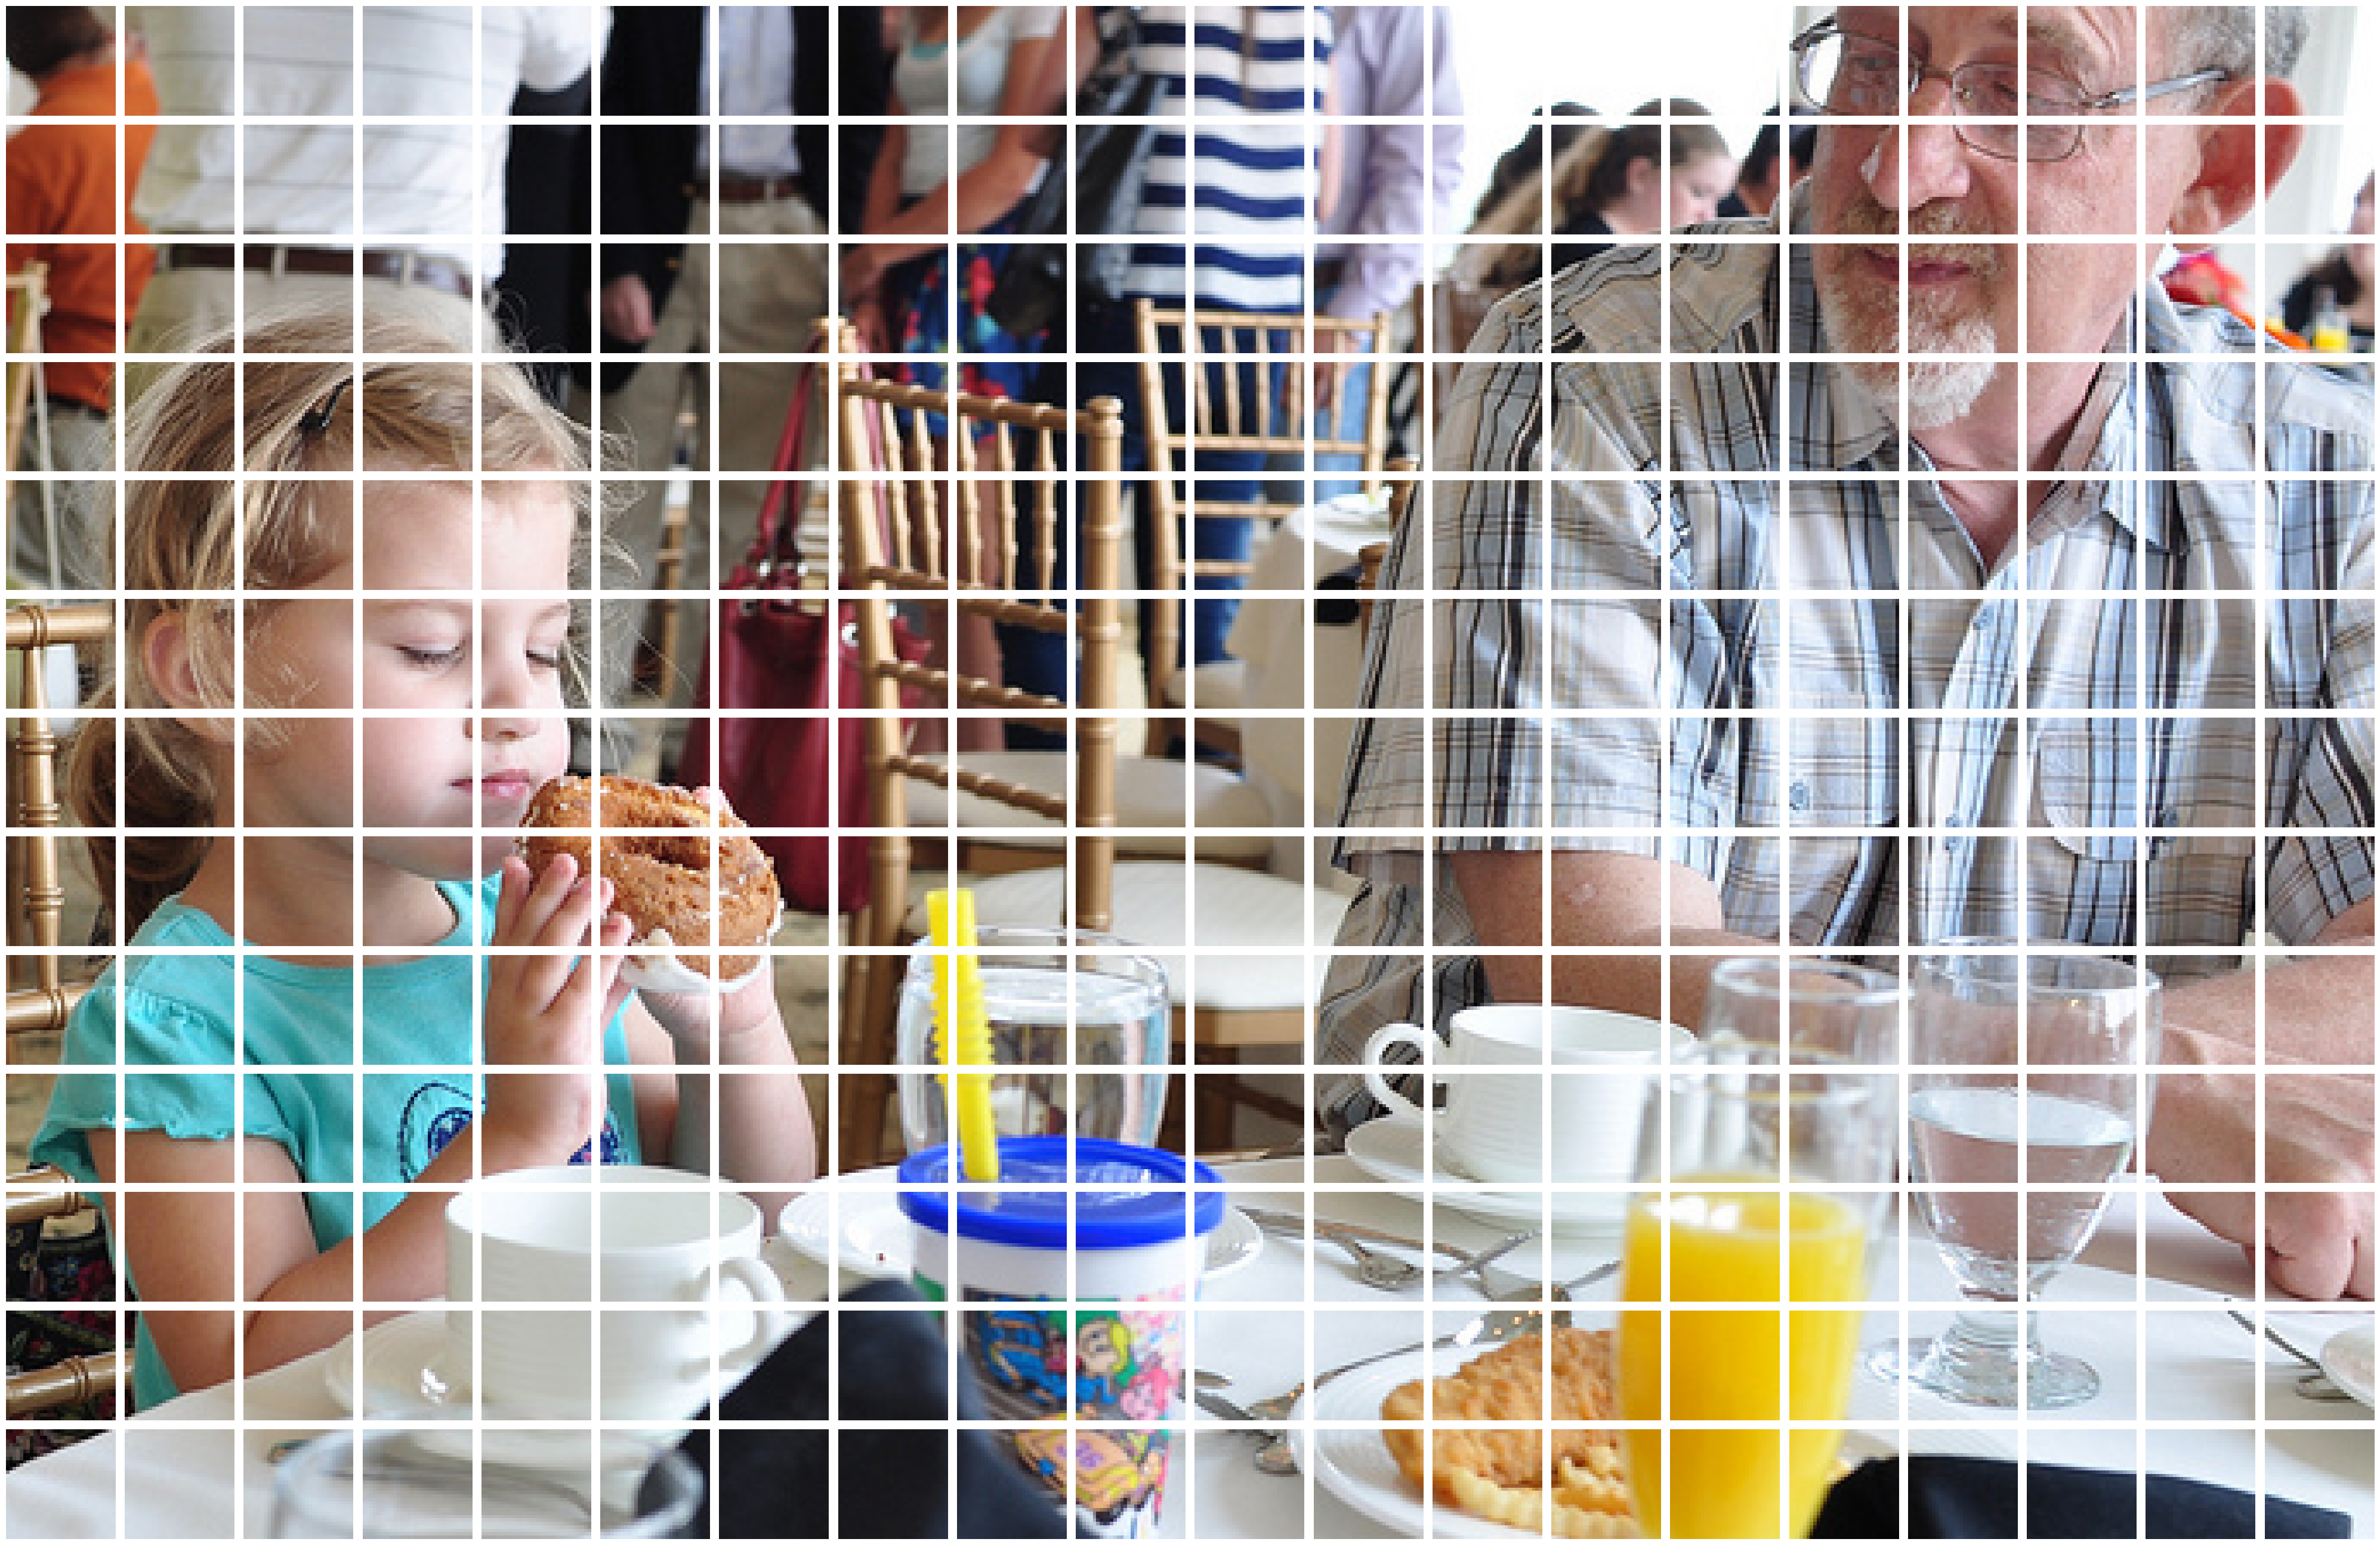

In [ ]:
window_size = 32

windowed_image  = image.unfold(0,3,3)
windowed_image.shape

windowed_image = windowed_image.unfold(1,window_size,window_size)
x = windowed_image.shape[1]



#################################################################
#             PLOT THE HORIZONTAL CHUNKING ONLY
#################################################################

#fig, ax = plt.subplots(x,1, figsize=(40, 26))
#
#for x in range(x):
#        ax[x].imshow(windows[0,x].to('cpu').permute(2,0,1))
#        ax[x].axis('off')
#
#fig.tight_layout()
#plt.show()


windowed_image = windowed_image.unfold(2,window_size,window_size)
print('Tensor shape:',windowed_image.shape)

y = windowed_image.shape[2]

fig, ax = plt.subplots(x, y, figsize=(2*y, 2*x))
for i in range(y):
        for j in range(x):
                ax[j,i].imshow(windowed_image[0,j,i].to('cpu').permute(1,2,0))
                ax[j,i].axis('off')

fig.tight_layout()
plt.show()

## Load CLIP
Load the model to evaluate the kernel (a N x N subset of the grid that will slide along all the image).

In [ ]:
import numpy as np
import torch
import clip

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("RN50")
model.to(device).eval()
input_resolution = model.visual.input_resolution
context_length = model.context_length
vocab_size = model.vocab_size
print("Device:", device)
print("Model parameters:", f"{np.sum([int(np.prod(p.shape)) for p in model.parameters()]):,}")
print("Input resolution:", input_resolution)
print("Context length:", context_length)
print("Vocab size:", vocab_size)

100%|███████████████████████████████████████| 244M/244M [00:04<00:00, 58.1MiB/s]


Device: cuda
Model parameters: 102,007,137
Input resolution: 224
Context length: 77
Vocab size: 49408


## Run the CLIP convolution

First we have a function that computes the score of each chunk of the image. The score is based on how much is similar to the query (based on CLIP).

In [ ]:
def computeScores(windows,stride = 1,kernel_size = 6, text = 'a donut'):
  device = "cuda" if torch.cuda.is_available() else "cpu"
  #txt_embedding = text2embedding(text)
  text_input = clip.tokenize([text]).to(device)

  heatmap = torch.zeros(windows.shape[1], windows.shape[2])
  #Count how many time each window is used as a kernel, in order to normalize the results
  # in the heatmap score
  number_of_uses = torch.ones(windows.shape[1], windows.shape[2])

  for i in range(0, windows.shape[1] - kernel_size + 1, stride):
          for j in range(0, windows.shape[2] - kernel_size + 1, stride):
                  #Initialize the canvas as a black image
                  canvas = torch.zeros(window_size*kernel_size, window_size*kernel_size, 3).to(device)
                  #print(canvas.shape)

                  kernel = windows[0,i:i+kernel_size,j:j+kernel_size].to(device)
                  #print(kernel.shape)
                  #Add each window of the kernel to the canvas
                  for k in range(kernel.shape[1]):
                          for l in range(kernel.shape[0]):
                                  canvas[k*window_size:(k+1)*window_size, l*window_size:(l+1)*window_size] += kernel[k,l].permute(1,2,0)

                  #plt.imshow(canvas)
                  #plt.show()
                  #print('original')
                  #print(canvas.shape)
                  canvas = canvas.permute(2,0,1)
                  #print(canvas.shape)
                  canvas_PIL = transforms.ToPILImage()(canvas)

                  canvas_input = preprocess(canvas_PIL).unsqueeze(0).to(device)

                  #Clip classification
                  with torch.no_grad():
                          logits_per_image, logits_per_text = model(canvas_input, text_input)
                          similarity = logits_per_image.to('cpu').item()


                  heatmap[i:i+kernel_size,j:j+kernel_size] += similarity
                  number_of_uses[i:i+kernel_size,j:j+kernel_size] += 1
                  #print("kernel similarity:", similarity)  # prints: [[0.9927937  0.00421068 0.00299572]]

  heatmap = heatmap / number_of_uses
  print(f'Result for the prompt:"{text}"')
  return heatmap

Then we create a function that plot the image based on the similarity score tensor.

It takes as input the similarity score tensor (referred as heatmap), the windowed image and the number of clipping.

The ``` num_clipping ``` parameter controls the number of time we **clip** the values. By clip (do not mistake with CLIP) we mean the mathematical __characteristic function__ (as the function that returns 0 if the value is less than 0 and returns the value itself otherwise).
Every time we clip, prior to clipping we subtract the mean. This is done because the values are very similar to each other so we compute the mean to get the average score and then "black out" chunks that are lower or equal to that averaged score.

In [ ]:
def visualizeCLIPconv(heatmap, windows, num_clipping = 3):
  device = "cuda" if torch.cuda.is_available() else "cpu"
  augmented_scores = heatmap.clone().to('cpu')
  for i in range(num_clipping):
    augmented_scores = np.clip(augmented_scores-augmented_scores.mean(), 0, np.inf)
  augmented_scores = (augmented_scores - augmented_scores.min())/(augmented_scores.max() - augmented_scores.min())

  #Make a copy of the tensor
  hm = windows.clone().to('cpu')
  #Need to match this two
  #print(hm.shape)
  #print(heatmap.shape)

  hm = hm.squeeze(0)
  #print(hm.shape)
  hm = hm.permute(3,4,0,1,2)
  #print(hm.shape)
  #Put the number of channels at the end
  hm = hm.permute(0,1,4,2,3)
  #print('final',hm.shape)
  hm = hm*augmented_scores
  #Reorder
  #In order to print they have to be
  #print(windows.shape)
  hm = hm.permute(3,4,2,0,1).unsqueeze(0)

  #Print the results
  fig, ax = plt.subplots(x, y, figsize=(0.5*y, 0.5*x))
  for i in range(y):
          for j in range(x):
                  ax[j,i].imshow(hm[0,j,i].to('cpu').permute(1,2,0))
                  ax[j,i].axis('off')
                  ax[j,i].set_aspect('equal')

  fig.subplots_adjust(wspace=0.0,hspace=0.0)
  plt.show()


Result for the prompt:"a donut"


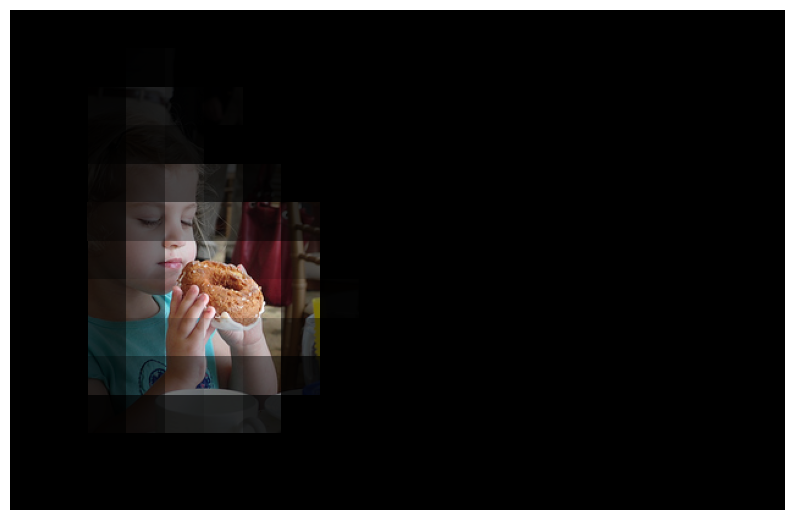

In [ ]:
CLIP_similarity_score_matrix = computeScores(windowed_image,
                                             stride = 1,
                                             kernel_size = 3,
                                             text = 'a donut')
visualizeCLIPconv(CLIP_similarity_score_matrix,windowed_image)

Result for the prompt:"a chair"


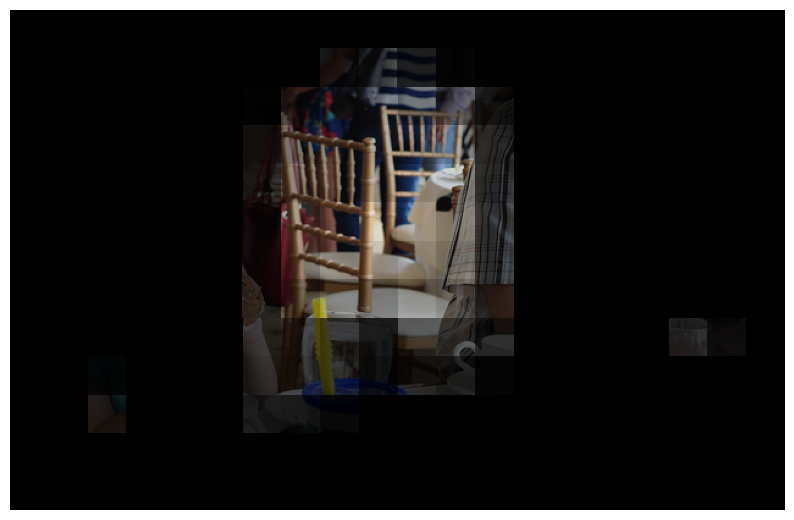

In [ ]:
CLIP_similarity_score_matrix = computeScores(windowed_image,
                                             stride = 1,
                                             kernel_size = 3,
                                             text = 'a chair')
visualizeCLIPconv(CLIP_similarity_score_matrix,windowed_image)

Result for the prompt:"an old man"


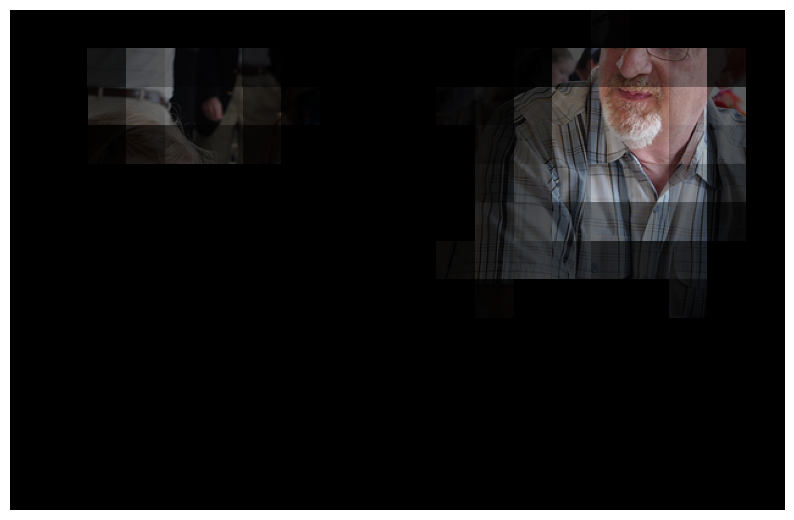

In [ ]:
CLIP_similarity_score_matrix = computeScores(windowed_image,
                                             stride = 1,
                                             kernel_size = 3,
                                             text = 'an old man')
visualizeCLIPconv(CLIP_similarity_score_matrix,windowed_image)

In this last example we can see that having a smaller kernel size can increase the precision but cause the model to not capture the full object.

On the other hand if we increase the kernel size we could incur into the opposite problem (not very precise, as we get a very big "aura" around the object)

## Results
If we tweak the parameters correctly it is possible to achieve good results in blacking out all the non relevant part of the image.
Sadly, for the sake of this project was not feasible to have the model learn and optimize those parameters runtime (as the first part of the pipeline) because of the time required to compute a single step (around few seconds, that do not scall well for training the complete model since we have like >40000 CLIP steps to perform).
The complete list of parameters that can be changed to get better results at each step are:
```
window_size
stride
kernel_size
num_clipping
```

So we opted to just find the parameters that would perform good enough on average, run on the complete dataset and save the results as our final dataset. In this way while training the model we don't need to compute the CLIP step at all (as it is already stored in the dataset we made).


Anyway here are some example results that made us very optimistic about this pipeline:

Result for the prompt:"a donut"


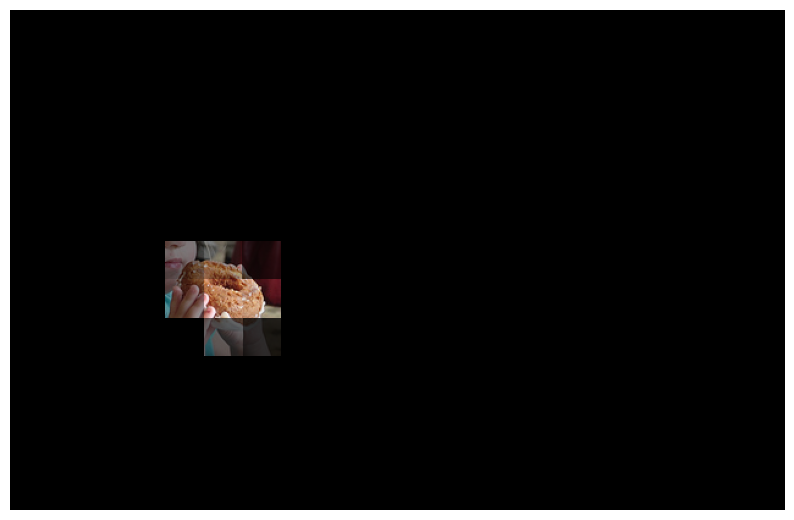

Result for the prompt:"an orange juice"


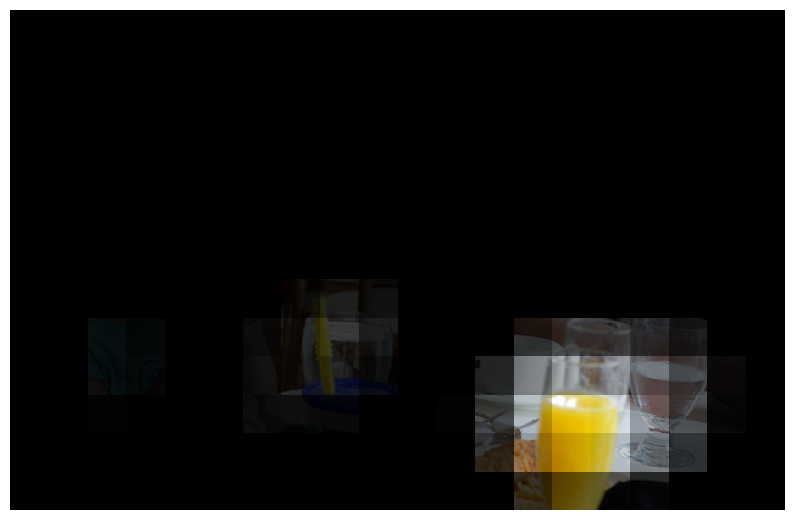

Result for the prompt:"the picture of a joung girl eating"


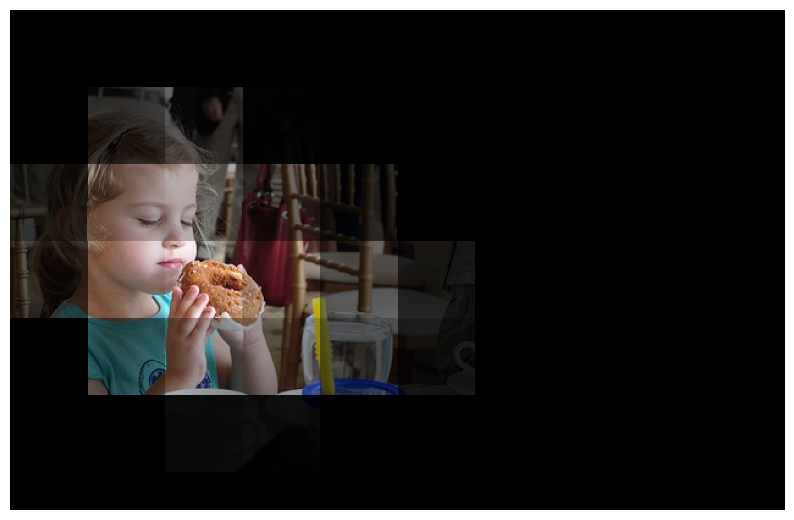

Result for the prompt:"a red purse"


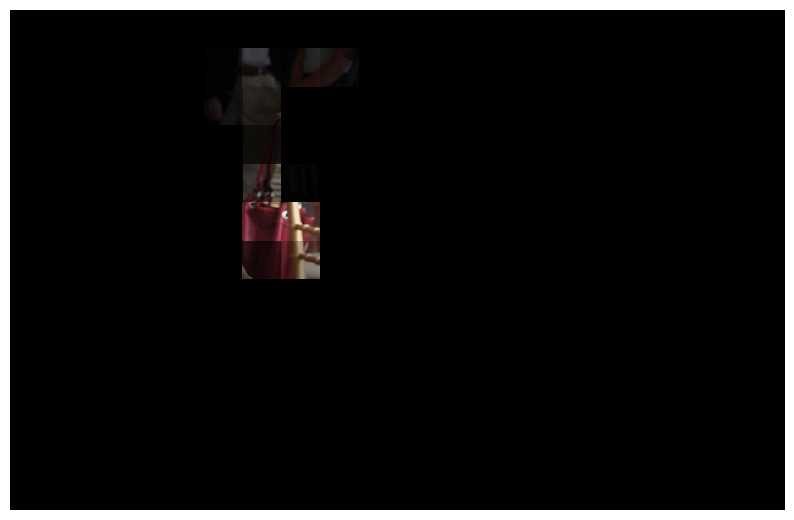

In [ ]:
CLIP_similarity_score_matrix = computeScores(windowed_image,
                                             stride = 1,
                                             kernel_size = 3,
                                             text = 'a donut')
visualizeCLIPconv(CLIP_similarity_score_matrix,windowed_image,50)
##########################################################################
CLIP_similarity_score_matrix = computeScores(windowed_image,
                                             stride = 1,
                                             kernel_size = 3,
                                             text = 'an orange juice')
visualizeCLIPconv(CLIP_similarity_score_matrix,windowed_image)
##########################################################################
CLIP_similarity_score_matrix = computeScores(windowed_image,
                                             stride = 2,
                                             kernel_size = 6,
                                             text = 'the picture of a joung girl eating')
visualizeCLIPconv(CLIP_similarity_score_matrix,windowed_image)
##########################################################################
CLIP_similarity_score_matrix = computeScores(windowed_image,
                                             stride = 1,
                                             kernel_size = 2,
                                             text = 'a red purse')
visualizeCLIPconv(CLIP_similarity_score_matrix,windowed_image,20)
##########################################################################

## Negative results
What happens if we look for an object that is not present in the image? Or that the CLIP model can't understand?

Lets show the results!


Result for the prompt:"a trenitalia train that is not late"


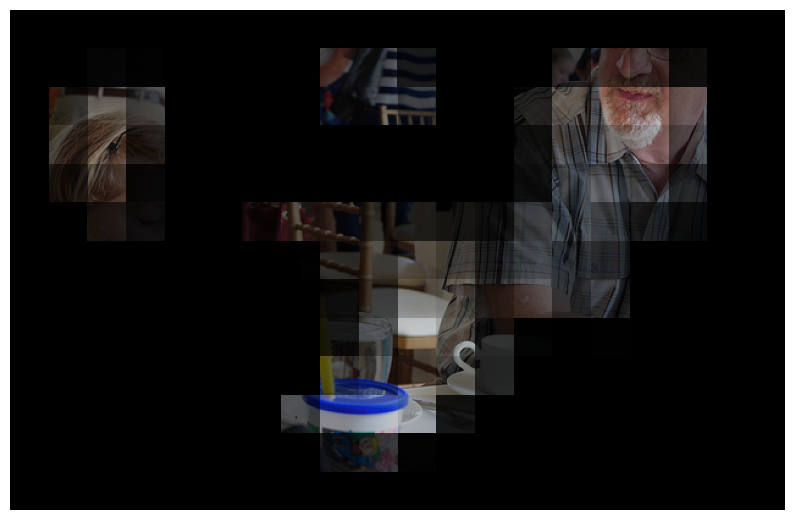

Result for the prompt:"a LLM that is not thought to be sentient by the general public"


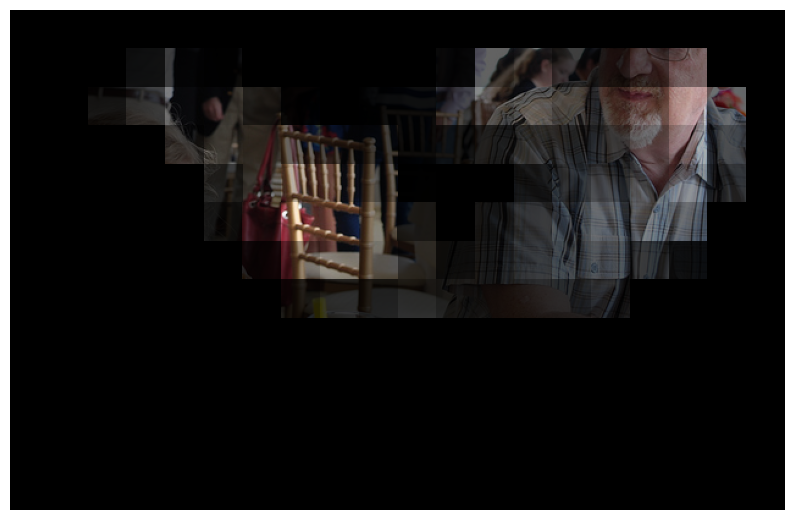

Result for the prompt:"airplane"


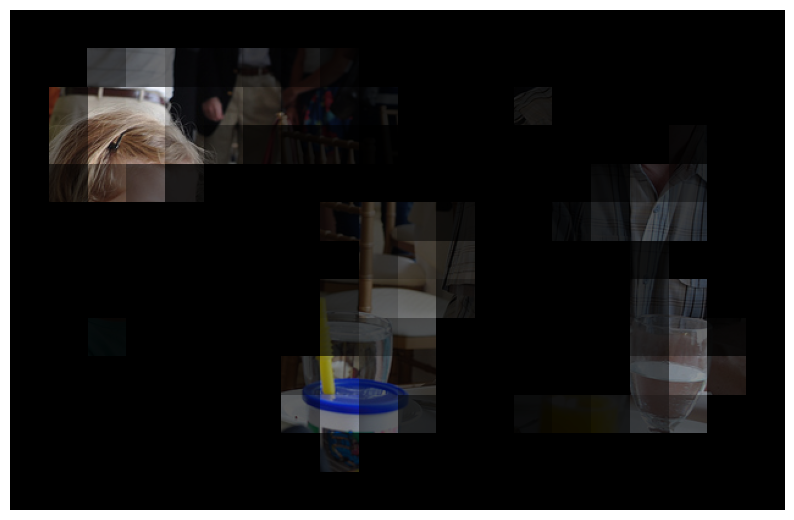

In [ ]:
CLIP_similarity_score_matrix = computeScores(windowed_image,
                                             stride = 1,
                                             kernel_size = 3,
                                             text = 'a trenitalia train that is not late')
visualizeCLIPconv(CLIP_similarity_score_matrix,windowed_image,3)
CLIP_similarity_score_matrix = computeScores(windowed_image,
                                             stride = 1,
                                             kernel_size = 3,
                                             text = 'a LLM that is not thought to be sentient by the general public')
visualizeCLIPconv(CLIP_similarity_score_matrix,windowed_image,3)
CLIP_similarity_score_matrix = computeScores(windowed_image,
                                             stride = 1,
                                             kernel_size = 3,
                                             text = 'airplane')
visualizeCLIPconv(CLIP_similarity_score_matrix,windowed_image,3)

As you can see even with "negative" or wrong prompts there are always active part of the image, this is due to the normalization step that rearranges the similarity values in the range [min_value, max_value].
This should not be a problem because during training the model is always prompted with description of existing objects within the image, but anyway it is worth considering this behaviour.


---
# Dataset

## Making the dataset


The dataset creation is a very long process that takes > 4 hours only for the training set, so we already prepared it in the drive with all the files needed at each step (from REFCOCO to our preprocess dataset). To avoid running the code by mistake (that would cause the dataset to be re-created from scratch taking a lot of time) we disabled the code.

You can inspect the code for the dataset creation down below, if you want to create it from scratch just set the variable
```
createDataset = True
```
and then run all the blocks.

In [ ]:
createDataset = False

To use the refcocog dataset we used the following code to place all the images with their corresponding labels:

In [ ]:
from tqdm import tqdm
import pandas as pd
import os
import shutil
from PIL import Image
import pickle
import json

if(createDataset):
  ds = submission_folder_path + 'Datasets/'
  out = submission_folder_path + 'Datasets/generated/'
  zip_path = submission_folder_path + 'Datasets/images.zip'
  extract_path = submission_folder_path + 'Datasets/imagesMixed/'
  obj = pd.read_pickle(ds + 'annotations/refs(umd).p')

  with open(ds + 'annotations/instances.json', 'r') as file:
      jdat = json.load(file)

  idk = obj

  found = []
  saved = []
  failed = []
  i=0

  '''
  #Drive file limit, so we need to unzip at each run:
  import zipfile
  try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
  except:
    print('Error with',zip_path)
  ##
  '''

The files all have the train name so we need to copy them into another folder with the correct names:

In [ ]:
if(createDataset):
  files =  os.listdir(ds+'imagesMixed/') #all files have train label

  for ref in obj:
      for file in files:
          if file[:-4] == ref['file_name'][:27]:
              file_path = os.path.join(ds+'imagesRenamed/', file)
              name = 'COCO_{}2014_{}.jpg'.format(ref['split'],file[-16:-4])
              shutil.copy2(file_path, ds+'imagesRenamed/'+name)

Finally we can select the split we want to make and we assign each photo all the labels and bounding boxes that it has

In [ ]:
if(createDataset):
  files =  os.listdir(ds+'imagesRenamed/')

  ################################################################################
  #                                  TRAIN
  ################################################################################
  labels = []
  dataset = []
  split = 'train/' #specify what split to make
  print('Creating ',split,' dataset')
  files = [s for s in files if s.find(split[:-1]) != -1] #ignore the data from other splits

  for file in tqdm(files):
      #Find the labels of the image
      for ref in obj:
          refname = 'COCO_{}2014_{:012d}.jpg'.format(ref['split'],ref['image_id'])
          if file == refname:
              labels.append(ref)
      #Find the bbox data
      anns = []
      for ann in jdat['annotations']:
          for ref2 in labels:
              if ann['image_id'] == ref2['image_id']:
                  anns.append(ann)
      #Remove possible dupplicates
      labann = []
      for label in labels:
          for ann in anns:
              if ann['id'] == label['ann_id']:
                  labann.append({'label':label, 'annotation':ann})
      lb = []
      seen = set()
      for item in labann:
          item_json = json.dumps(item, sort_keys=True)
          if item_json not in seen:
              lb.append(item)
              seen.add(item_json)
      #Error check
      if len(lb) == 0:
          print('ERROR')
          break

      #Read the image data
      file_path = os.path.join(ds+'imagesRenamed/', file)
      im = Image.open(file_path)
      try:
        image = {
            'pixels': im.tobytes(),
            'size': im.size,
            'mode': im.mode,
        }
      except:
        print('no')
      im=0
      labels =[]

      #Save the new pickle file
      for i in range(len(lb)):
          f = {'img': image, 'label': lb[i]['label'], 'annotation':lb[i]['annotation']}
          #print(ds +'final/'+split+ file[:-4] +'_lbl'+str(i)+ '.p')
          with open(ds +'final/'+split+ file[:-4] +'_lbl'+str(i)+ '.p', 'wb') as pkl:
              pickle.dump(f, pkl)

      image=0

  ################################################################################
  #                                  TEST
  ################################################################################

  labels = []
  dataset = []
  split = 'test/' #specify what split to make
  print('Creating ',split,' dataset')
  files = [s for s in files if s.find(split[:-1]) != -1] #ignore the data from other splits

  for file in tqdm(files):
      #Find the labels of the image
      for ref in obj:
          refname = 'COCO_{}2014_{:012d}.jpg'.format(ref['split'],ref['image_id'])
          if file == refname:
              labels.append(ref)
      #Find the bbox data
      anns = []
      for ann in jdat['annotations']:
          for ref2 in labels:
              if ann['image_id'] == ref2['image_id']:
                  anns.append(ann)
      #Remove possible dupplicates
      labann = []
      for label in labels:
          for ann in anns:
              if ann['id'] == label['ann_id']:
                  labann.append({'label':label, 'annotation':ann})
      lb = []
      seen = set()
      for item in labann:
          item_json = json.dumps(item, sort_keys=True)
          if item_json not in seen:
              lb.append(item)
              seen.add(item_json)
      #Error check
      if len(lb) == 0:
          print('ERROR')
          break

      #Read the image data
      file_path = os.path.join(ds+'imagesRenamed/', file)
      im = Image.open(file_path)
      try:
        image = {
            'pixels': im.tobytes(),
            'size': im.size,
            'mode': im.mode,
        }
      except:
        print('no')
      im=0
      labels =[]

      #Save the new pickle file
      for i in range(len(lb)):
          f = {'img': image, 'label': lb[i]['label'], 'annotation':lb[i]['annotation']}
          #print(ds +'final/'+split+ file[:-4] +'_lbl'+str(i)+ '.p')
          with open(ds +'final/'+split+ file[:-4] +'_lbl'+str(i)+ '.p', 'wb') as pkl:
              pickle.dump(f, pkl)

      image=0

  ################################################################################
  #                              VALITDATION
  ################################################################################

  labels = []
  dataset = []
  split = 'val/' #specify what split to make
  print('Creating ',split,' dataset')
  files = [s for s in files if s.find(split[:-1]) != -1] #ignore the data from other splits

  for file in tqdm(files):
      #Find the labels of the image
      for ref in obj:
          refname = 'COCO_{}2014_{:012d}.jpg'.format(ref['split'],ref['image_id'])
          if file == refname:
              labels.append(ref)
      #Find the bbox data
      anns = []
      for ann in jdat['annotations']:
          for ref2 in labels:
              if ann['image_id'] == ref2['image_id']:
                  anns.append(ann)
      #Remove possible dupplicates
      labann = []
      for label in labels:
          for ann in anns:
              if ann['id'] == label['ann_id']:
                  labann.append({'label':label, 'annotation':ann})
      lb = []
      seen = set()
      for item in labann:
          item_json = json.dumps(item, sort_keys=True)
          if item_json not in seen:
              lb.append(item)
              seen.add(item_json)
      #Error check
      if len(lb) == 0:
          print('ERROR')
          break

      #Read the image data
      file_path = os.path.join(ds+'imagesRenamed/', file)
      im = Image.open(file_path)
      try:
        image = {
            'pixels': im.tobytes(),
            'size': im.size,
            'mode': im.mode,
        }
      except:
        print('no')
      im=0
      labels =[]

      #Save the new pickle file
      for i in range(len(lb)):
          f = {'img': image, 'label': lb[i]['label'], 'annotation':lb[i]['annotation']}
          #print(ds +'final/'+split+ file[:-4] +'_lbl'+str(i)+ '.p')
          with open(ds +'final/'+split+ file[:-4] +'_lbl'+str(i)+ '.p', 'wb') as pkl:
              pickle.dump(f, pkl)

      image=0

100%|██████████| 515/515 [01:59<00:00,  4.31it/s]


After running the code above we end up with a pickle for each image mentioned in the ref(umd).p file, with the structue:


```
{'img': image, 'label': labels, 'annotation': annotations}
```

Where the labels contained all the sentences for the respective image, and the annotations contained the bounding box data.

Following this we tested a couple of variations of the dataset:

*   Have repeated images with different labels (complete dataset)
*   Have all images with a single label (almost half of the complete dataset)

And we found that **using the complete dataset didn't improve performance of our model**



## Clip Preprocessing

We used clip to preprocess the training data by applying a 16x16 moving similarity kernel, alongside using Bert to enconde the image labels

In [ ]:
#specify split to make
split = 'val/'

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as tt
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import pickle
import clip
from transformers import BertTokenizer, BertModel
import gc
from torchvision import transforms


if(createDataset):
  torch.backends.cudnn.benchmark = True
  path = ds+'final/'

  device = "cuda" if torch.cuda.is_available() else "cpu"
  print(device)
  batch_size = 1
  resize = 512
  window_size=32

  toTensor = transforms.ToTensor()

  stride = 1
  kernel_size =8
  plot = False

  def loadData(path,split):
      files =  os.listdir(path + split)
      dataset = []
      for file in files:
          file_path = os.path.join(path+split, file)

          dataset.append(file_path)
      return dataset

  class CustomDataset(Dataset):
      def __init__(self, data):
          self.data = data

      def __len__(self):
          return len(self.data)

      def __getitem__(self, idx):
          with open(self.data[idx], 'rb') as file:
              data = pickle.load(file)
              if True:
                  label = [data['label']['sentences'][0]['raw']] #take the first label raw
                  annotation = data['annotation']['bbox']
                  img = Image.frombytes(data['img']['mode'],
                                        data['img']['size'],
                                        data['img']['pixels'])
                  #turn the image into floats [0,1]
                  img = np.transpose(np.array(img, dtype=np.float32)/255)
                  #format as rgb b&w images
                  if img.shape[0] != 3:
                      img = np.repeat(img[np.newaxis, :,:],3,axis=0)
                  #to tensor and resize
                  img = torch.tensor(img)
                  transform = tt.Resize((resize,resize), interpolation=tt.InterpolationMode.BICUBIC, antialias=True)
                  img = transform(img)
                  #bounding box resize
                  rsize = [data['img']['size'][0]/img.size()[1],
                          data['img']['size'][1]/img.size()[2]]
                  bbox = [annotation[0]/rsize[0], annotation[1]/rsize[1],
                          annotation[2]/rsize[0], annotation[3]/rsize[1]]

          return {'img':img,
                'label':label,
                'bbox':torch.tensor(bbox)}

  #CREATE THE DATALOADER
  def create_data_loader_CustomDataset(data, batch_size, eval=False):
      ds = CustomDataset(data=data)
      if not eval:
          return DataLoader(ds, batch_size=batch_size, shuffle=True), len(ds)
      else:
          return DataLoader(ds, batch_size=batch_size, shuffle=False), len(ds)

  #load the file paths
  dataset = loadData(path, split)
  #specify only first label or all labels
  dataset = [f for f in dataset if f[-3] == '0']
  #load the data
  train_dl, train_length = create_data_loader_CustomDataset(dataset, batch_size, eval=True)

  #Load the models
  clipM, preprocess = clip.load("RN50", device=device)
  clipM.to(device).eval()
  input_resolution = clipM.visual.input_resolution
  context_length = clipM.context_length
  vocab_size = clipM.vocab_size
  tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
  bertM = BertModel.from_pretrained("bert-base-uncased")
  bertM.to(device).eval()

  #chop the image into chunks
  def bwindowize(image,window_size):
          windows  = image.permute(0,3,2,1)
          windows = windows.unfold(1,window_size,window_size)
          x = windows.shape[1]
          #Also permute x and y torch.Size([2, 16, 16, 3, 32, 32])
          windows = windows.unfold(2,window_size,window_size)
          y = windows.shape[2]
          return windows,x,y

  #Clip's internal preprocessing
  transforms = torch.nn.Sequential(
                  tt.Resize((224,224), antialias=True, interpolation=Image.BICUBIC),
                  tt.Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711)),
                  )
  preprocess = torch.jit.script(transforms)

  def bcomputeHeatmap(windows,window_size,x_size,batch_size,model,tok_labels,device):
          patches = windows.unfold(1, kernel_size, stride)
          patches = windows.unfold(1, kernel_size, stride).unfold(2, kernel_size, stride)
          # Extract all possible 3x3 kernels with stride 1 from the 16x16 checkboard in dimension 0
          #From torch.Size([4, 11, 11, 3, 32, 32, 6, 6])
          #To torch.Size([4, 11, 6, 32, 11, 6, 32, 3])
          #Or to torch.Size([4, 11, 11, 6, 32, 6, 32, 3])
          patches = patches.permute(0,1,2,6,4,7,5,3)
          resulting_kernels = patches.reshape(batch_size, (x_size-kernel_size+1)**2, window_size*kernel_size, window_size*kernel_size,3)
          # The resulting tensor has shape torch.Size([4, 121, 192, 192, 3])

          #First unify all the batches
          resulting_kernels = resulting_kernels.reshape(batch_size*(x_size-kernel_size+1)**2, window_size*kernel_size, window_size*kernel_size,3)
          # Put the channel as the second dimension in order to apply the preprocessing
          # And also fed them to the model
          resulting_kernels = resulting_kernels.permute(0,3,1,2)
          # Compute the similarity score for each kernel of each image from the batch
          # 1)First we need to preprocess all the images
          # torch.Size([484, 192, 192, 3])
          preprocess_input = preprocess(resulting_kernels)
          # Reshape the tensor to the original shape
          preprocess_input = preprocess_input.reshape(batch_size, (x_size-kernel_size+1)**2,3,224,224).permute(0,1,3,4,2)
          # Move the number of channels before the height and width
          preprocess_input = preprocess_input.permute(0,1,4,2,3)
          '''
          Similarity has to be a tensor of size [batch_size,16,16]
          Need to first reshape the 81 tensor to 9x9
          '''
          similarity = torch.zeros(batch_size,x_size,x_size).to(device)
          n_of_runs = torch.zeros(batch_size,x_size,x_size).to(device)

          # 2)Then we need to compute the similarity score for each image
          for batch_index in range(batch_size):
                  text_input = clip.tokenize(tok_labels[batch_index]).to(device)
                  logits_per_image, logits_per_text = clipM(preprocess_input[batch_index], text_input)
                  #print(batch_index,logits_per_image.shape)
                  sim_score = logits_per_image.squeeze(1).reshape(kernel_size+1,kernel_size+1).to(device)

                  gc.collect()
                  torch.cuda.empty_cache()
                  # Don't store anything for now
                  with torch.no_grad():
                      for i in range(kernel_size+1):
                          for j in range(kernel_size+1):
                                  similarity[batch_index, i:i+kernel_size, j:j+kernel_size] += sim_score[i,j]
                                  n_of_runs[batch_index, i:i+kernel_size, j:j+kernel_size] += 1


                  gc.collect()
                  torch.cuda.empty_cache()
          return similarity/n_of_runs

  def preprocessing(images,label):
      #Dimension should be [batch_size,x_size,y_size,3,window_size,window_size]
      windowed_images,x_size,y_size = bwindowize(images, window_size)
      windowed_images,x_size,y_size = bwindowize(images, window_size)
      #Compute the heatmap score for each kernel
      heatmaps_scores = bcomputeHeatmap(windowed_images, window_size, x_size,batch_size, clipM,label, device)
      #First, put every score one after the other
      heatmaps_scores = heatmaps_scores.reshape(batch_size,x_size**2)
      normalize = True
      if(normalize):
          tensor_mean = heatmaps_scores.mean(dim=1).unsqueeze(-1)
          #Choose to clip negative values basically removing data
          heatmaps_scores = (heatmaps_scores - tensor_mean).clamp(min= -tensor_mean.item()/10, max = float('inf'))
          tensor_min = heatmaps_scores.min(dim=1).values.clone().unsqueeze(-1)
          tensor_max = heatmaps_scores.max(dim=1).values.clone().unsqueeze(-1)
          heatmaps_scores = (heatmaps_scores - tensor_min)/(tensor_max - tensor_min)


      # Transform the tensor to apply the multiplication
      heatmaps_scores = heatmaps_scores.reshape(batch_size,x_size,x_size).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
      windowed_images = windowed_images*heatmaps_scores

      #Rebuild chunks into images
      recImgs = windowed_images.permute(0,3,2,5,1,4) #[1,16a,16b,3,32,32] -> [1,3,16b,32,16a,32]
      recImgs = recImgs.reshape(batch_size,3,512,512)

      #Encode label with bert
      bertLabels = torch.zeros(batch_size,768)
      for i in range(0,batch_size):
          encoded_input = tokenizer(label[i], return_tensors='pt').to(device)
          output = bertM(**encoded_input).last_hidden_state[0][0] #768 size
          bertLabels[i] = output
      gc.collect()

      return recImgs, bertLabels

  print("Model parameters:", f"{np.sum([int(np.prod(p.shape)) for p in clipM.parameters()]):,}")
  print("Input resolution:", input_resolution)
  print("Context length:", context_length)
  print("Vocab size:", vocab_size)

  #Function to convert image into ycbcr, used for an experimental model, now it's irrelevant
  def rgb2ycbcr(image: torch.Tensor):
      r: torch.Tensor = image[..., 0,:,:]
      g: torch.Tensor = image[..., 1,:,:]
      b: torch.Tensor = image[..., 2,:,:]
      delta: float = 0.5
      y: torch.Tensor = 0.299*r+0.587*g+0.114*b
      cb: torch.Tensor = (b-y)*0.564+delta
      cr: torch.Tensor = (r-y)*0.713+delta
      return torch.stack([y,cb,cr], -3)

  def ycbcr2rgb(image: torch.Tensor):
      y: torch.Tensor = image[..., 0,:,:]
      cb: torch.Tensor = image[..., 1,:,:]
      cr: torch.Tensor = image[..., 2,:,:]
      delta: float = 0.5
      r: torch.Tensor = y + 1.403 * (cr - delta)
      g: torch.Tensor = y - 0.714 * (cr - delta) - 0.344 * (cb - delta)
      b: torch.Tensor = y + 1.773 * (cb - delta)
      return torch.stack([r,g,b], -3).clamp(0,1)


  for epoch in range(1, 2):
      print(len(dataset))
      i=0
      #replace train_dl with the others to create the other parts
      for bi, data in tqdm(enumerate(train_dl), total=int(len(dataset)/train_dl.batch_size)):

          images,label,bbox = data['img'], data['label'][0], data['bbox']
          images = images.to(device)
          bbox = bbox.to(device)
          #Run the preprocessing
          recImgs, bertLabels = preprocessing(images, label)
          #convert to ycbcr
          yim = rgb2ycbcr(images)
          yrecim = rgb2ycbcr(recImgs)
          #mix processed luminance with original chroma components
          mix = torch.cat((yrecim[:,0,:,:].unsqueeze(1),yim[:,1:,:,:]), 1).to('cpu')

          recImgs,bertLabels,label,bbox =recImgs.to('cpu'),bertLabels.to('cpu'),label,bbox.to('cpu')
          #To plot a processed image use: plt.imshow(recImgs.squeeze(0).permute(2,1,0).to('cpu'))

          with open(path+'processed/'+split+dataset[i].split("/")[-1], 'wb') as f:
              pickle.dump({'img': recImgs, 'Blabel':bertLabels, 'label':label, 'bbox':bbox, 'mix':mix}, f)
          i+=1

cuda


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Model parameters: 102,007,137
Input resolution: 224
Context length: 77
Vocab size: 49408
515


100%|██████████| 515/515 [25:00<00:00,  2.91s/it]


---
# Model

## BXfinder

Imports and configurations

In [4]:
import os
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as tt
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
from torchvision import transforms
import torchvision.ops as tvo
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights

from PIL import Image
from transformers import BertTokenizer, BertModel
import time
import datetime

wb = False

path = submission_folder_path+'Datasets/final/processed/'
spath = submission_folder_path+'Datasets/model_checkpoints/epochs/'
n_epochs = 50
init_lr = 5e-5
clipping_value = 1 #gradient clip
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
save_freq =5
batch_size = 32
resize = 256
window_size=32
plot = False

cuda


## Dataloader

In [5]:
def loadData(path,split):
    files =  os.listdir(path + split)
    dataset = []
    for file in files:
        file_path = os.path.join(path+split, file)

        dataset.append(file_path)
    return dataset

class CustomDatasetPP(Dataset):

    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        with open(self.data[idx], 'rb') as file:
            data = pickle.load(file)
            if True:
                label = data['label'] #take the first label raw
                bbox = data['bbox']*resize/512
                #To use ycbcr images -> img = F.interpolate(data['mix'], (resize,resize), mode='bicubic', antialias=True)
                img = F.interpolate(data['img'], (resize,resize), mode='bicubic', antialias=True)
                blabel = data['Blabel']

                #normalize the images
                mean = [0.5, 0.5, 0.5]  # Mean values for each channel
                std = [0.5, 0.5, 0.5]   # Standard deviation values for each channel
                normalize = transforms.Normalize(mean, std)
                img = normalize(img)

        img.requires_grad=False
        blabel.requires_grad=False
        bbox.requires_grad=False

        return {'img': img[0],
              'label': label,
              'blabel':blabel[0],
              'bbox':bbox[0]}

#CREATE THE DATALOADER
def create_data_loader_CustomDataset(data, batch_size, eval=False):
    ds = CustomDatasetPP(data=data)

    if not eval:
        return DataLoader(ds, batch_size=batch_size, shuffle=True), len(ds)

    else:
        return DataLoader(ds, batch_size=batch_size, shuffle=False), len(ds)

## The Model

The following model takes the initial part of the FASTERRCNN v2 network, which are 5 self-attention blocks that output 5 tensors at the intermediate attention levels:

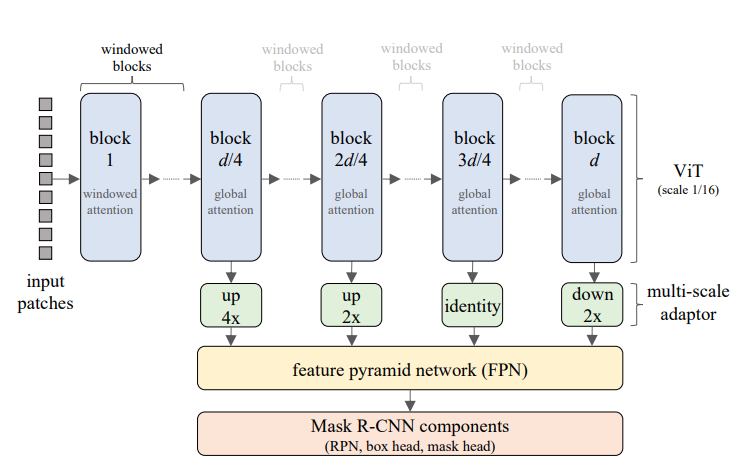

The model then takes this outputs and concatenates them together by upsampling until reaching the largest size which is [256, resize/4, resize/4], so concatenated the final number of channels is 320. To perform the upsampling we used PixelShuffle which has proven to give better results in retaining image quality while at the same time reducing the number of operations.
This tensor is then downsampled through a resnet reducing the number of channels to 9.


From here the model takes the BERT encodings from the label of the images and runs them through a fully connected layer that changes their size from 768 to resize/4 * resize/4 *3.
After this the labels are reshaped into a tensor with the shape [3, resize/4, resize/4].


Now we reshape the data into a bigger tensor of size [3, resize/2, resize/2] composed by the first 3 channels of the image tensor on the top left corner, the next 3 channels on the top right, the remaining 3 channels on the bottom left and the bert tensor in the bottom right part.


This tensor is sent again into the initial attention blocks of the RCNN model, which as explained before returns 5 tensors of different sizes, so we use the same upsampling from before just ignoring the 5th output because it's too small. Here we're using another jump connection that sums the 3rd output of the first attention blocks with the upsampled second output of this attention blocks.
After all the upsampling we end with a tensor size [320, resize/8, resize/8] which is again downsampled to 9 channels.

After this we flatten this tensor and run it through a fully connected network that gives us the 4 numbers of the coordinates of the bounding box.

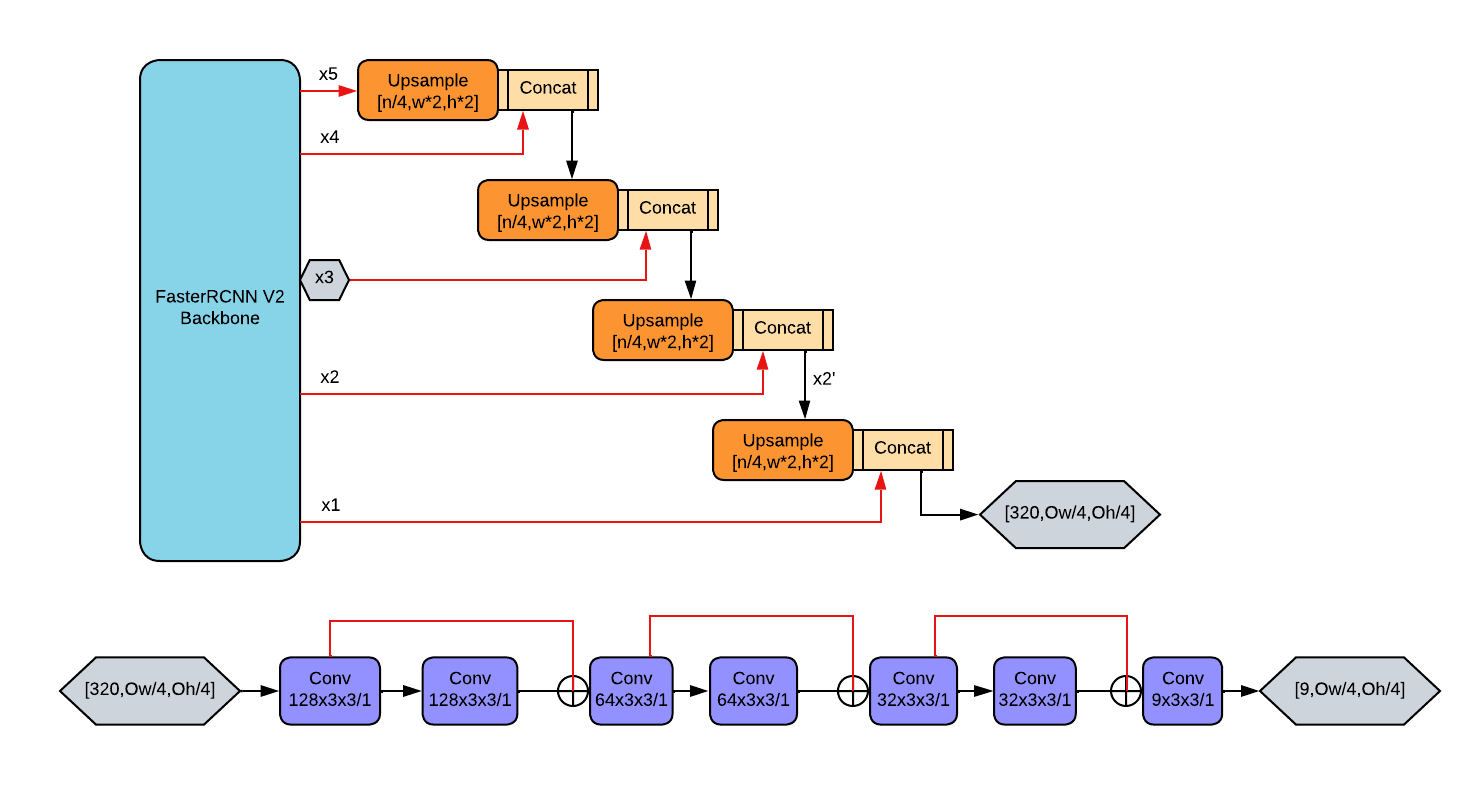

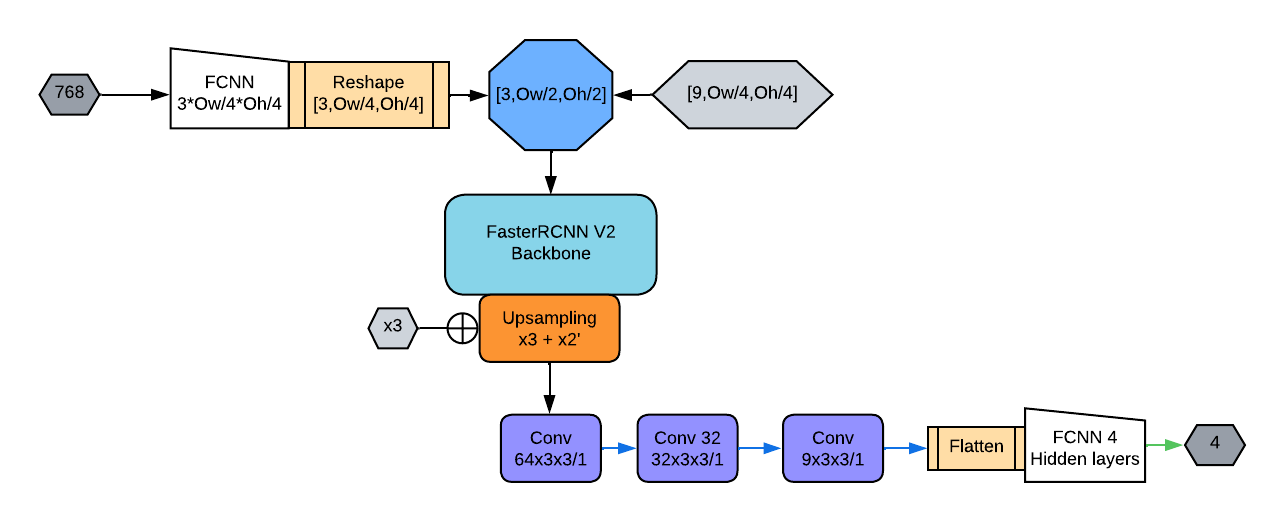

The black connections are using the Mish activation function (which has been shown to provide a consistent improvement in performance), the blue use LeakyReLU, green uses Sigmoid and red has no activation function.

Another relevant thing to point out is the use of kaiming normal initialization for the convolutions. It showed better results compared to using the default pytorch initialization only if the convolution is followed by a LeakyReLU-type activation function

In [6]:
weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights, trainable_backbone_layers=5)
model2 = fasterrcnn_resnet50_fpn_v2(weights=weights, trainable_backbone_layers=5)

def conv(ni, nf, ks=3, stride=1, padding=1, **kwargs):
        _conv = nn.Conv2d(ni, nf, kernel_size=ks,stride=stride,padding=padding, **kwargs)
        nn.init.kaiming_normal_(_conv.weight, mode='fan_out')
        return _conv

class BXfinder(nn.Module):
    def __init__(self):
        super(BXfinder, self).__init__()

        self.flat = nn.Flatten()
        self.L1 = nn.Sequential(conv(17,8,3,1,1,padding_mode='reflect'),
                                nn.Mish(inplace=True),
                                conv(8,3,3,1,1,padding_mode='reflect'),
                                nn.Mish(inplace=True),
                                )

        self.L2 = nn.Sequential(nn.Linear(768, 2048),
                                nn.Mish(inplace=True),
                                nn.Linear(2048, int(resize/4)*int(resize/4)*3),
                                nn.Mish(inplace=True),
                                )
        self.L3 = nn.Sequential(nn.Linear(int(resize/8)*int(resize/8)*9, 4096),
                                nn.Mish(inplace=True),
                                nn.Linear(4096, 8192),
                                nn.Mish(inplace=True),
                                nn.Linear(8192, 8192),
                                nn.Mish(inplace=True),
                                nn.Linear(8192, 2048),
                                nn.Mish(inplace=True),
                                nn.Linear(2048, 512),
                                nn.Mish(inplace=True),
                                nn.Linear(512, 4),
                                nn.Sigmoid()
                                )

        self.idk2 = nn.Sequential(conv(320,64,3,1,1,padding_mode='reflect'),
                                  nn.LeakyReLU(),
                                  conv(64,32,3,1,1,padding_mode='reflect'),
                                  nn.LeakyReLU(),
                                  conv(32,9,3,1,1,padding_mode='reflect'),
                                  nn.LeakyReLU())

        self.r1 = nn.Conv2d(320,128,3,1,1,padding_mode='reflect')

        self.r2 = nn.Sequential(nn.Mish(inplace=True),
                                conv(128,128,3,1,1,padding_mode='reflect'),
                                nn.Mish(inplace=True),
                                )
        self.r3 = nn.Conv2d(128,64,3,1,1,padding_mode='reflect')
        self.r4 = nn.Sequential(nn.Mish(inplace=True),
                                conv(64,64,3,1,1,padding_mode='reflect'),
                                nn.Mish(inplace=True),)
        self.r5 = nn.Conv2d(64,32,3,1,1,padding_mode='reflect')
        self.r6 = nn.Sequential(nn.Mish(inplace=True),
                                conv(32,32,3,1,1,padding_mode='reflect'),
                                nn.Mish(inplace=True),)
        self.r7 = nn.Conv2d(32,9,3,1,1,padding_mode='reflect')

        self.up5 = nn.Sequential(conv(256, 256,3,1,1,padding_mode='reflect'),
                                nn.Mish(inplace=True),
                                nn.PixelShuffle(2))
        self.up4 = nn.Sequential(conv(256+64, 256,3,1,1,padding_mode='reflect'),
                                nn.Mish(inplace=True),
                                nn.PixelShuffle(2))


        self.idk = model.backbone
        self.lol = model2.backbone

    def forward(self,x, bertx):
        # Pass the image though the attention blocks
        x = self.idk(x) #Initial Decomposition Kernels
        #Extract the outpus
        x1 = x.popitem(last=False)[1]
        x2 = x.popitem(last=False)[1]
        x3 = x.popitem(last=False)[1]
        x4 = x.popitem(last=False)[1]
        x5 = x.popitem(last=False)[1]

        #Upsampling block
        x5 = self.up5(x5) #256,2,2 -> 64,4,4
        x4 = torch.cat((x4,x5), dim=1) # 256+64,4,4
        x4 = self.up4(x4) #320,4,4 -> 64,8,8
        x3 = torch.cat((x3,x4), dim=1) # 256+64,8,8
        x3 = self.up4(x3) #320,8,8 -> 64,16,16
        x2 = torch.cat((x2,x3), dim=1) # 256+64,16,16
        x2 = self.up4(x2) #320,16,16 -> 64,32,32
        x1 = torch.cat((x1,x2), dim=1) # 256+64,32,32

        #Residual encoder blocks 320 -> 9
        x = self.r1(x1)
        x = self.r2(x) + x
        x = self.r3(x)
        x = self.r4(x) + x
        x = self.r5(x)
        x = self.r6(x) + x
        x = self.r7(x)

        #Prepare image to be joined with bert
        top_left = x[:, :3, :, :]
        top_right = x[:, 3:6, :, :]
        bottom_left = x[:, 6:, :, :]

        #Process bert embeddings as a matrix
        bertx = self.L2(bertx) #768 -> 1024
        bertx = bertx.reshape(-1, 3, int(resize/4), int(resize/4))

        #Join the data
        xx = torch.zeros((bertx.shape[0], 3, int(resize/2), int(resize/2)), device=torch.device(device))#.to(device)
        xx[:, :, :int(resize/4), :int(resize/4)] = top_left
        xx[:, :, :int(resize/4), int(resize/4):] = top_right
        xx[:, :, int(resize/4):, :int(resize/4)] = bottom_left
        xx[:, :, int(resize/4):, int(resize/4):] = bertx

        #Pass the joint data into the attention blocks
        x = self.lol(xx) #Link Output Labels
        #Extract the outputs
        x1 = x.popitem(last=False)[1]
        x2 = x.popitem(last=False)[1]
        x3b = x.popitem(last=False)[1]
        x4 = x.popitem(last=False)[1]

        #Upsampling block with jump connection x2 + x3
        x4 = self.up5(x4)
        x3b = torch.cat((x3b,x4), dim=1)
        x3b = self.up4(x3b)
        x2 = torch.cat((x2,x3b), dim=1)
        x2 = self.up4(x2) + x3
        x1 = torch.cat((x1,x2), dim=1)

        #Compress the data
        x = self.idk2(x1) # 320,16,16 -> 9,16,16
        #Flatten and final fully connected layer
        x = self.flat(x)
        x = self.L3(x)
        #output is between [0,1] so we multiply it by resize-1
        return x*(resize-1)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth
100%|██████████| 167M/167M [00:00<00:00, 238MB/s]


## Loss

For the loss we first tried only using a iou based loss available in pytorch, which goes from 0 to 2, but this led to poor performance. We also tried using only a corner based loss where we use the MSE of the goal corners of the bounding box with the model output and it performed better that only the iou loss but still wasn't optimal.

We decided to combine both, initially using a geometric mean between the means of both losses, then we switched to using the sum of each bbox error for both losses and still use the geometric mean, and for the loss below we use a simple multiplication divided by the size of the input image and the batch size to normalize it up to a point and be able to compare it with results that use different batch sizes and image sizes.

In [7]:
criterion = nn.MSELoss()

def final_loss(outputs, bbox):
    #Get the MSE values of each corner of the bbox
    loss = 0
    for i in range(0,4):
        loss += criterion(outputs.transpose(1,0)[i], bbox.transpose(1,0)[i])

    #Get the iou loss and ignore the iou's of boxes that are negative and use the mean instead
    neg = tvo.generalized_box_iou_loss(outputs,bbox)
    if (neg < 0).any():
        mask = neg >= 0
        pos = torch.masked_select(neg, mask)
        l1 = torch.mean(pos)
    else:
        l1 = tvo.generalized_box_iou_loss(outputs,bbox,reduction='sum')
    l2 = loss
    #Make the loss multi-objective and normalize it
    return (l1*l2)/(resize*bbox.size(0))

## Training & Testing


For training we used AdamW as it has shown consistent better performance over Adam. We also use gradient clipping to combat exploding gradients.

Regarding data augmentation, we tried implementing color jitter which is known for increasing performance but in this case the model was severly affected by it, and any other type of value shifting augmentation for that matter.

We decided to use a batch size 32 because it was the limit our GPU allowed us to use. The size of the images was set to 256 because it presented a clear advantage over 128 (it seems the bigger the image the better performance gets). For the model to run without needing specific changes in the sizes of the tensors in the structure the model needs to receive as input images with sizes of base 2.

IT MAY CRASH FOR NO REASON DUE TO COLAB -_-

In [8]:
if True:
    torch.backends.cudnn.benchmark = True

    train_ds = loadData(path, 'train/')
    val_ds = loadData(path, 'val/')
    test_ds = loadData(path, 'test/')

    print(len(train_ds), len(val_ds), len(test_ds))

    train_dl, train_length = create_data_loader_CustomDataset(train_ds, batch_size, eval=False)
    val_dl, train_length = create_data_loader_CustomDataset(val_ds, batch_size, eval=True)
    test_dl, train_length = create_data_loader_CustomDataset(test_ds, 1, eval=True)

    #Model
    boxfinder = BXfinder();
    boxfinder.to(device)
    #Load the pretrained backbones
    model.backbone.to(device)
    model2.backbone.to(device)
    optimizer = torch.optim.AdamW(boxfinder.parameters(), lr=init_lr)

    #Training and Validation loops
    elapsed_time=0
    for epoch in range(1, n_epochs+1):
        start_time = time.time()
        train_loss = 0.0
        val_loss= 0.0
        print(epoch, 'ETA: ' + str(datetime.timedelta(seconds = elapsed_time*n_epochs+1-epoch)))

        #Training loop
        boxfinder.train()
        i=0
        iou = []
        for bi, data in tqdm(enumerate(train_dl), total=int(len(train_ds)/train_dl.batch_size)):

            images,label,bbox = data['img'], data['label'][0], data['bbox']
            images = images.to(device)
            bbox = bbox.to(device)
            #Turn the bbox data from 2 coordinates + width and heigth to 4 coordinates
            bbox[:,2] = bbox[:,0]+bbox[:,2]
            bbox[:,3] = bbox[:,1]+bbox[:,3]

            recImgs = images
            bertLabels = data['blabel']
            images.requires_grad=True
            bertLabels.requires_grad=True
            bbox.requires_grad=True

            #Process the data
            outputs = boxfinder(recImgs, bertLabels.to(device))

            #Loss and backprop
            loss = final_loss(outputs, bbox)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(boxfinder.parameters(), clipping_value)
            optimizer.step()
            train_loss += loss.item()*images.size(0)

            #Calculate iou
            for j in range(0,images.size(0)):
                temp = tvo.box_iou(bbox[j].unsqueeze(0),outputs[j].unsqueeze(0)).to('cpu')
                iou.append(temp.item())


            i+=1
            #break

        train_loss = train_loss/len(train_dl)
        print('E: {} T Loss: {:.3f}'.format(epoch, train_loss) + " %" + "{:.3}".format(np.exp(-abs(train_loss))*100))
        print(np.array(iou).mean())
        #Save model weights
        if epoch%save_freq == 0:
            try:
                torch.save(boxfinder.state_dict(), spath + 'epoch{0:05d}.pth'.format(epoch))
            except Exception as e:
                print("An error occurred:", e)

        #Validation loop
        boxfinder.eval()
        iou=[]
        with torch.no_grad():
            for bi, data in tqdm(enumerate(val_dl), total=int(len(val_ds)/val_dl.batch_size)):
                images,label,bbox = data['img'], data['label'][0], data['bbox']
                images = images.to(device)
                bbox = bbox.to(device)
                #Turn the bbox data from 2 coordinates + width and heigth to 4 coordinates
                bbox[:,2] = bbox[:,0]+bbox[:,2]
                bbox[:,3] = bbox[:,1]+bbox[:,3]

                recImgs = images
                bertLabels = data['blabel']

                #Process the data
                outputs = boxfinder(recImgs, bertLabels.to(device))

                #Calculate loss (used for plotting)
                loss = loss = final_loss(outputs, bbox)
                val_loss += loss.item()*images.size(0)

                #iou
                for j in range(0,images.size(0)):
                    temp = tvo.box_iou(bbox[j].unsqueeze(0),outputs[j].unsqueeze(0)).to('cpu')
                    iou.append(temp.item())


            val_loss = val_loss/len(val_dl)
            print('E: {} V Loss: {:.3f}'.format(epoch, val_loss) + " %" + "{:.3}".format(np.exp(-abs(val_loss))*100))
            print(np.array(iou).mean())
            print(outputs[0], bbox[0])


        elapsed_time = time.time() - start_time

    #Test loop
    with torch.no_grad():

        #Calculate test IOU
        iou = []
        for data in test_dl:
            images,label,bbox = data['img'], data['label'][0], data['bbox']
            bertLabels = data['blabel']
            images = images.to(device)
            bbox = bbox.to(device)
            bbox[:,2] = bbox[:,0]+bbox[:,2]
            bbox[:,3] = bbox[:,1]+bbox[:,3]

            outputs = boxfinder(images, bertLabels.to(device))
            temp = tvo.box_iou(bbox,outputs).to('cpu')
            iou.append(temp.item())
        print(np.array(iou).mean())


1000 515 2600
1 ETA: 0:00:00


32it [03:43,  6.98s/it]


E: 1 T Loss: 1816.266 %0.0
0.19842453765689788


17it [10:21, 36.53s/it]


E: 1 V Loss: 1546.095 %0.0
0.21354853074355684
tensor([ 57.5876,  45.6722, 180.7797, 207.4397], device='cuda:0') tensor([ 54.6655,  64.5760, 183.2859, 253.8440], device='cuda:0')
2 ETA: 11:43:53.943104


...

32it [01:15,  2.37s/it]


E: 50 T Loss: 2.653 %7.04
0.8384515156149864


17it [00:30,  1.81s/it]


E: 50 V Loss: 844.737 %0.0
0.3237443755982948
tensor([ 50.7501,  67.5387, 214.8286, 253.1982], device='cuda:0') tensor([ 54.6655,  64.5760, 183.2859, 253.8440], device='cuda:0')


OSError: ignored

## Use the model

Remember to run the initial configurations, the dataloader and the model!

In [ ]:
loaddir =  submission_folder_path + 'epoch00100F.pth'
device = "cuda" if torch.cuda.is_available() else "cpu"
verbose = False


boxfinder = BXfinder()
boxfinder = boxfinder.to(device)
boxfinder.load_state_dict(torch.load(loaddir, map_location=torch.device(device)))
boxfinder.eval()

test_ds = loadData(path, 'test/')
test_dl, train_length = create_data_loader_CustomDataset(test_ds, 1, eval=False)
#NEED TO ALSO LOAD OG IMAGES FOR PLOTTING

mean = [0.5, 0.5, 0.5]  # Mean values for each channel
std = [0.5, 0.5, 0.5]   # Standard deviation values for each channel

denormalize = transforms.Compose([
    transforms.Normalize(mean=[0, 0, 0], std=1 / np.array(std)),
    transforms.Normalize(mean=-np.array(mean), std=[1, 1, 1])
])


with torch.no_grad():
    iou = []
    i=0
    for data in test_dl:
        images,label,bbox = data['img'], data['label'][0], data['bbox']
        bertLabels = data['blabel']
        images = images.to(device)
        bbox = bbox.to(device)
        bbox[:,2] = bbox[:,0]+bbox[:,2]
        bbox[:,3] = bbox[:,1]+bbox[:,3]

        outputs = boxfinder(images, bertLabels.to(device))
        temp = tvo.box_iou(bbox,outputs).to('cpu')
        iou.append(temp.item())

        #Plot the image
        images = denormalize(images)
        image = images.squeeze(0).permute(2,1,0).to('cpu')
        fig, ax = plt.subplots()
        ax.imshow(image)
        plt.title(label[0])
        #Plot dataset bounding box
        x_down = data['bbox'][0][0].item()
        y_down = data['bbox'][0][1].item()
        w = data['bbox'][0][2].item()
        h = data['bbox'][0][3].item()
        if(verbose):
          print(x_down,y_down,w,h)
        rect = plt.Rectangle((x_down, y_down), w, h, linewidth=1, edgecolor='r', facecolor='none',alpha=0.3,color='r')
        ax.add_patch(rect)

        #plot model bbox
        if(verbose):
          print(outputs)
        outputs= outputs.to('cpu')
        w = outputs[:,2] - outputs[:,0]
        h = outputs[:,3] - outputs[:,1]
        if(verbose):
          print(outputs[:,0], outputs[:,1], w,h)
        rect = plt.Rectangle((outputs[:,0].item(), outputs[:,1].item()), w.item(), h.item(), linewidth=1, edgecolor='b', facecolor='none', alpha=0.3, color='b')
        ax.add_patch(rect)

        if i ==10:
          break

        i+=1
print('\n\n\nRED: Ground Truth\nBLUE: Predicted')
if(verbose):
  print(np.array(iou).mean())

Output hidden; open in https://colab.research.google.com to view.

---
# Results

Overall from what you can see in the cell above, the predictions are consistent and almost every time correct. The bigger problem here is that when there are multiple instances of the same object (e.g. two zebras) that correspond to the text label it ofter select the wrong one. This is what we think it is driving down the validation loss.
For example:

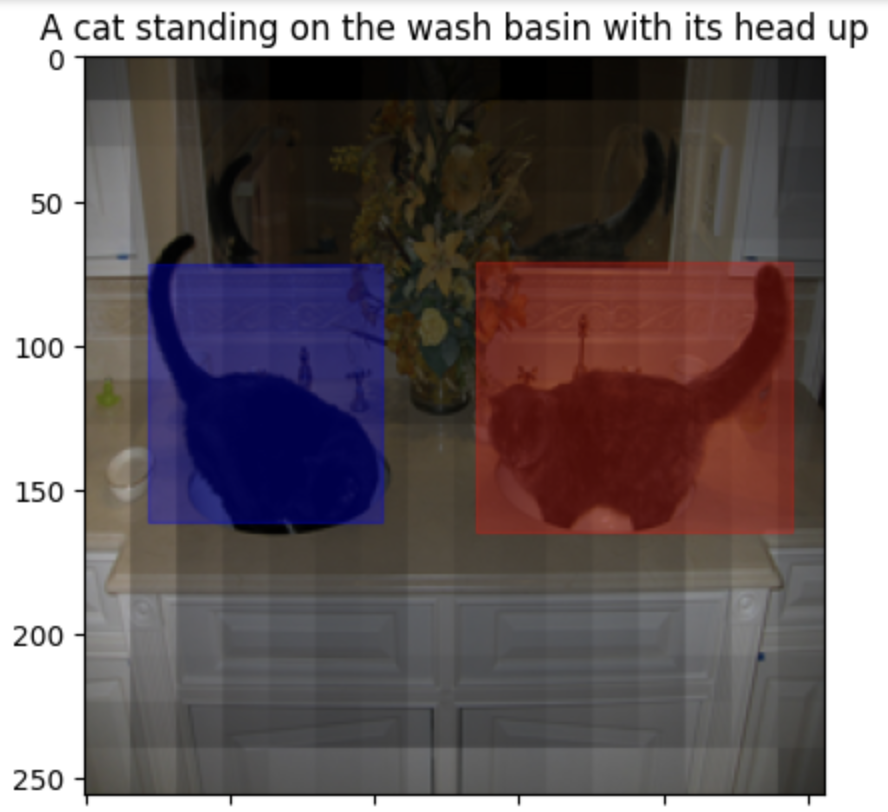

Let's analyze the results more in detail.

## Results
 We tried many different architectures, parameters and models to see which was the one performing better.
 The best runs can be visualized on Weight AND Biases. We deleted all the results that were showing that a particular model was not converging at all to keep it clean. In the following table we can see:


1.   **final norm 256 x2jump2** : This is the final model which all the configurations that can be found in the code above
2.   **mod4v2Sig-256** : This model doesn't have the x3 jump connection nor normalization of the input data
3.   **RCNN-Clip_Bert** : This structure uses only the initial attention blocks, it reduced the processed image matrix and flattened it to concatenate it with the bert embeddings and go directly to a fully connected layer. This model and the ones below were trained on 128 size images and have the same architecture
4.   **RCNN-Clip_NOBert** : Removed Bert from the model
5.   **RCNN_NO_Clip** : Removed the clip preprocessing from the images


| MODEL NAME                | Train IOU | Val IOU | Train Loss | Val Loss |
| :------------------------ | :-------: | ------: | ---------: | -------: |
| final norm 256 x2jump     |   0,9369  | 0,4455  | 0,2622     | 804,616  |
| mod4v2Sig-256             |   0,9354  | 0,4251  | 0,3303     | 893,239  |
| RCNN-Clip-Bert            |   0,9086  | 0,3301  | 7,707      | 331.181  |
| RCNN-Clip-NOBert          |   -       | -       | 265,239    | 893,239  |
| RCNN-NO-Clip              |   -       | -       | 8,527      | 419,313  |


Note: The loss used between models was changed and it's affected by the size of the input image

Even if the loss is not perfectly comparable, from those value we get a strong message: the CLIP preprocessing information is helping the model achieve better results **but** **BERT** is helping way more.

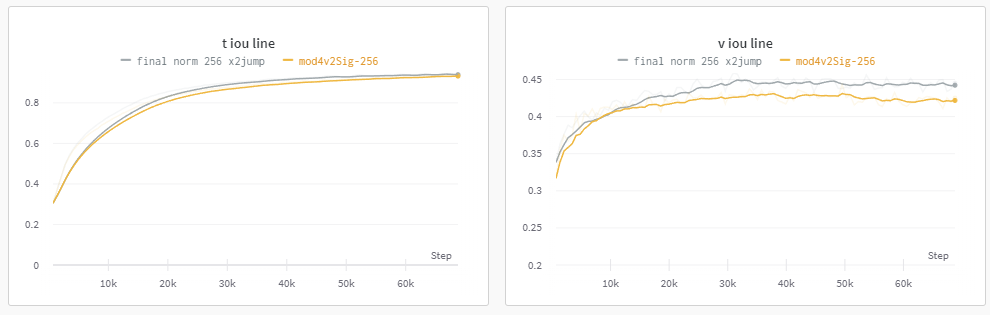

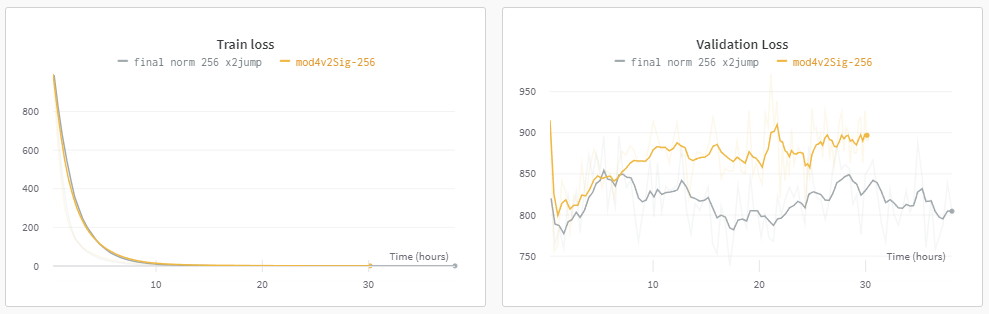

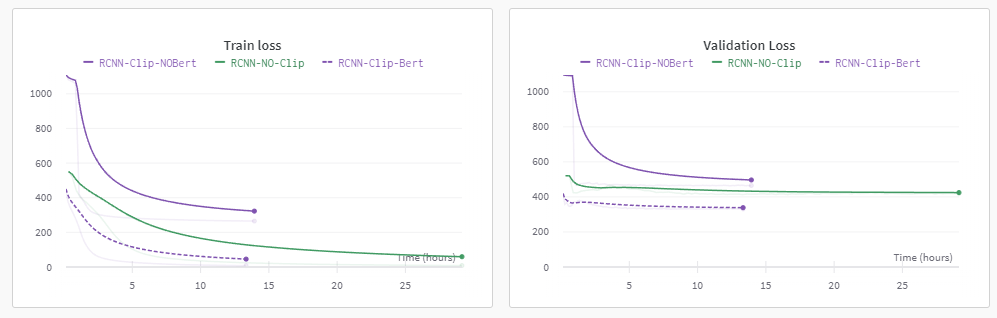

### 1. final norm 256 x2jump


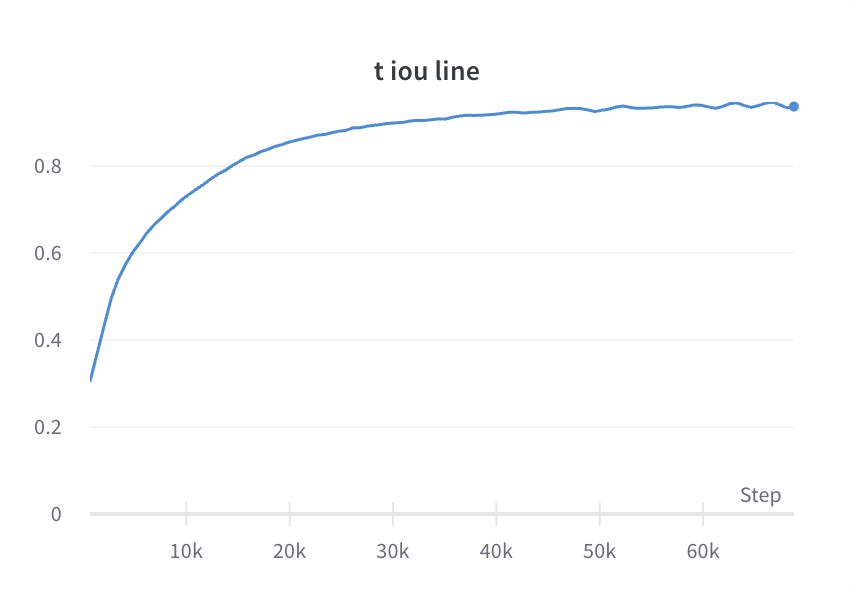

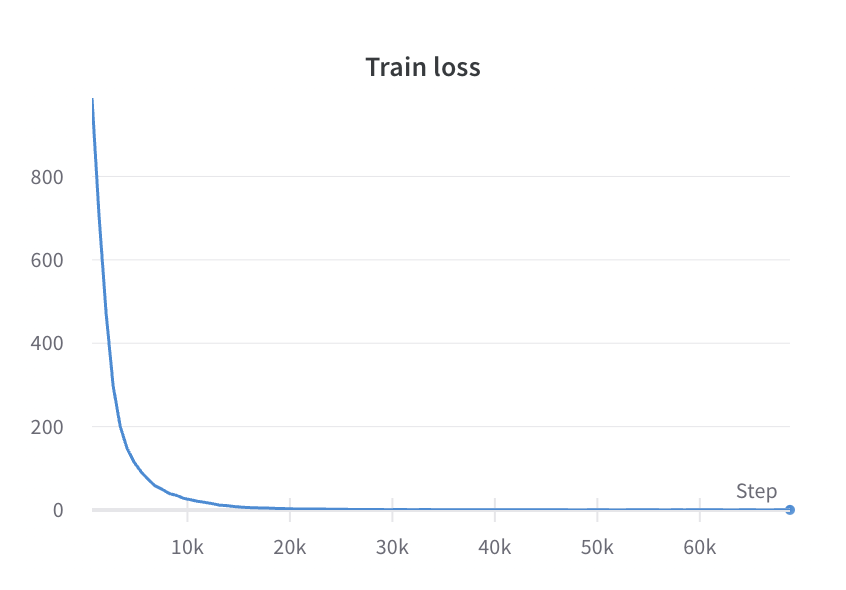

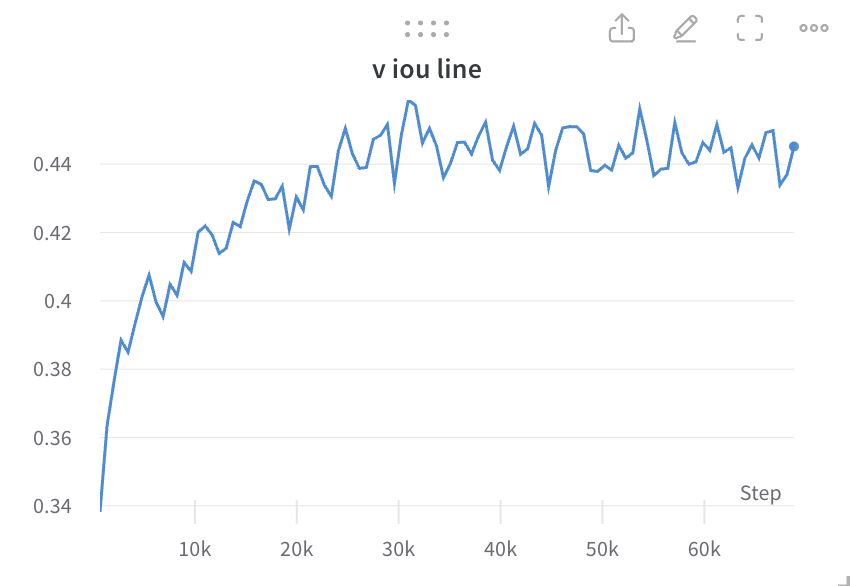

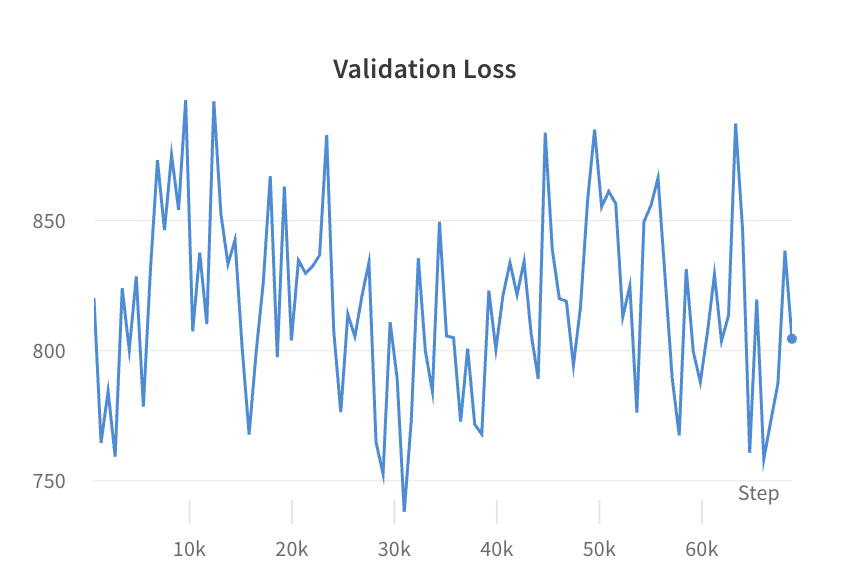

### 2. mod4v2Sig-256

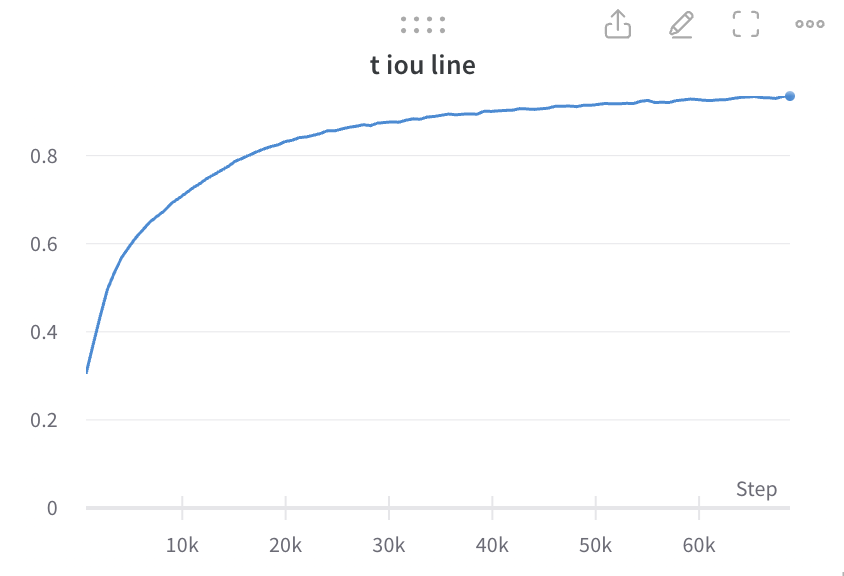

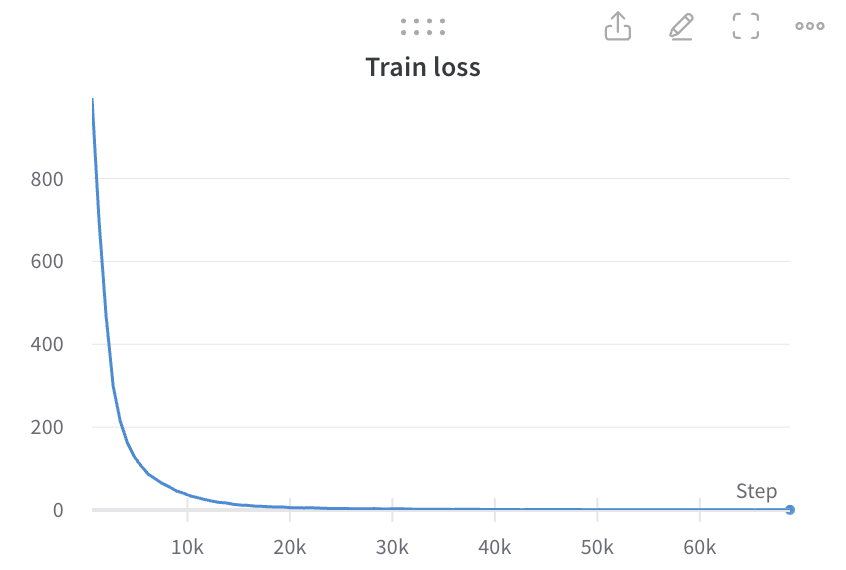

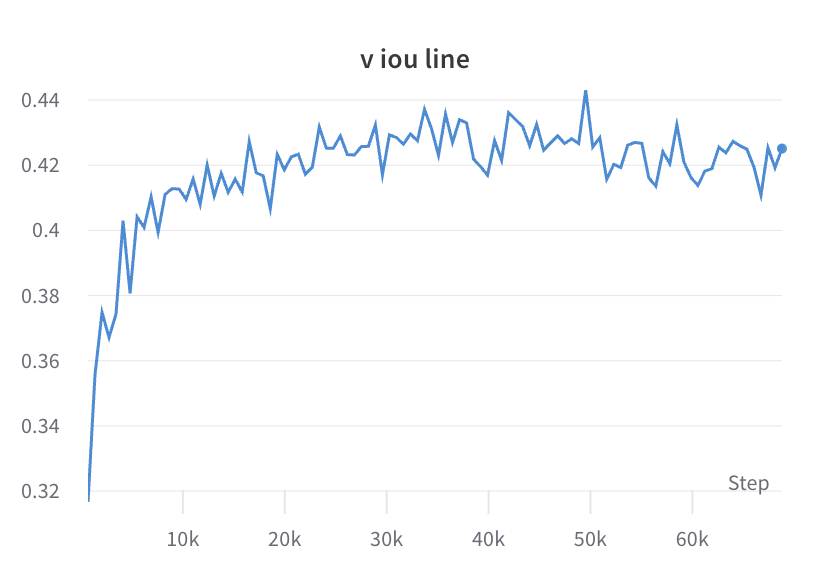

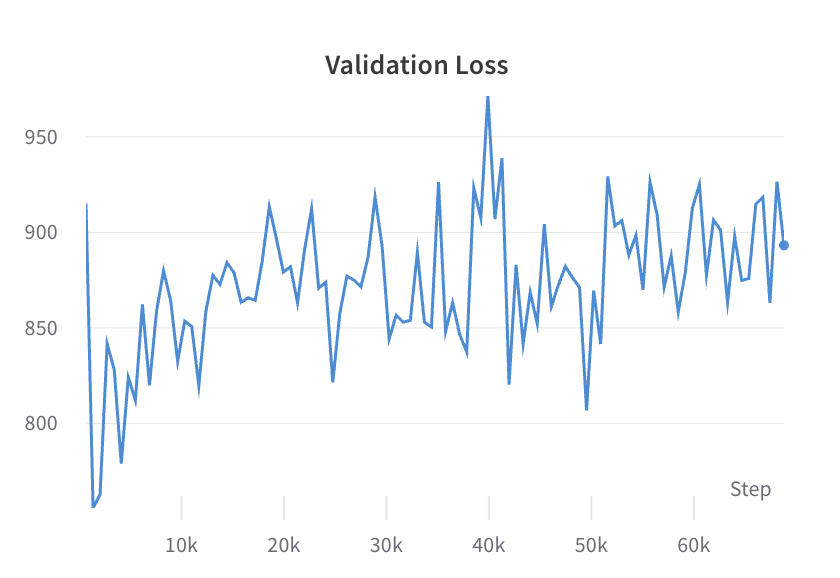

## Links
Our WANDB page can be found here:
https://wandb.ai/unitnais/visual-grounding.

Our GitHub repository can be found here:
https://github.com/debryu/visual-grounding.


---


# Future Work
Our project is far from perfect and actually we have some ideas on how we would like to fix some problems we encountered.
First, from the results we can see that the model is doing very good on the train set but it cannot generalize well and does poorly on the validations.

## Idea
One idea to have a more robust model is to approach the problem in a similar fashion as Language Models do in Masked Language Modeling:
the model produce the logits (the predicted probability for a specific token) and the loss is computed by the CROSS ENTROPY between the logits and the one hot encoding of the ground truth.
In the same way we could chunk the image into blocks as we did for computing the CLIP similarity score matrix and use this to predict a matrix of "logits" where each one describes the probability of that particular block to contain the object.

The loss is computed by the CROSS ENTROPY LOSS of those logits between the ground truth matrix which is a matrix composed by 0 if the block does not contain the bounding box of the object, 1 if it does, and 0.5 if the bounding box cuts (it does not full cover) the block.

Basically, this model will learn to predict a mask for the image that finds which element in the grid is relevant to the queried text. This is not really the same as we were doing with the CLIP similarity score because as we saw it cannot handle "negative prompts" (that are not present in the image) and also it is not a true mask layer (but just makes the image pixels go to 0 if they are not relevant).

## Things we might have done wrong

A posteriori if we were able to go back in time we would have changed little things that now we deem are actually holding us back.
One is the way we added the CLIP similarity score in the model, since we now believe that a better way to do it is to have the raw similarity matrix in the dataset and combine it in different ways at different steps instead of just applying it directly to the image.
In this way the model could have "jump connections" and access the raw CLIP similarity matrix at deeper layers for example.

The second important thing we noted could be problematic is the loss function: it was really hard to design one that would have not caused problems because of the generalized IOU returning values that pushed the model to predict bounding boxes as big as they could be.
We fixed that by weighting it by another loss that takes into consideration the distance between the corners. But of course, this could be further improved and it is not really a good solution.

## Other ideas

Another way of solving some issues, in particular the overfitting, is to either/both:
1.  Augment the dataset (color jittering, crop, rotation, etc.)
2.  Increase the model size and number of parameters

Another possibility is:
3.  Maybe CLIP is the bottleneck that is preventing the model to generalize

Actually we tried augmenting the dataset but we got worse results (so we did not spent too much time on it).
On the other hand, increasing the model size was not feasible since we have 12GB of VRAM and so we cannot run bigger models.

# Citations

[Deep Residual Learning for Image Recognition](https://arxiv.org/pdf/1512.03385.pdf)

---

[Benchmarking Detection Transfer Learning with Vision Transformers](https://arxiv.org/pdf/2111.11429.pdf)

---

[BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](https://arxiv.org/pdf/1810.04805.pdf)

---

[Generalized Intersection over Union: A Metric and A Loss for Bounding Box Regression](https://arxiv.org/pdf/1902.09630.pdf)

---

[Real-Time Single Image and Video Super-Resolution Using an Efficient Sub-Pixel Convolutional Neural Network](https://arxiv.org/pdf/1609.05158.pdf)

More on ESPCN:
[An Overview of ESPCN: An Efficient Sub-pixel Convolutional Neural Network](https://medium.com/@zhuocen93/an-overview-of-espcn-an-efficient-sub-pixel-convolutional-neural-network-b76d0a6c875e)

---

[Decoupled Weight Decay Regularization](https://arxiv.org/pdf/1711.05101.pdf)

---

[Real-Time Single Image and Video Super-Resolution Using an Efficient Sub-Pixel Convolutional Neural Network](https://arxiv.org/pdf/1609.05158.pdf)

---

[Mish: A Self Regularized Non-Monotonic Neural Activation Function](https://arxiv.org/pdf/1908.08681v1.pdf)

More on MISH:
[Meet Mish — New State of the Art AI Activation Function. The successor to ReLU?](https://lessw.medium.com/meet-mish-new-state-of-the-art-ai-activation-function-the-successor-to-relu-846a6d93471f)

---

[Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification](https://arxiv.org/pdf/1502.01852v1.pdf)

More on Kaiming Initialization:
[Weight initialization for CNNs: A Deep Dive into He Initialization](https://medium.com/@tylernisonoff/weight-initialization-for-cnns-a-deep-dive-into-he-initialization-50b03f37f53d)
